# Air Quality in Nairobi — PM2.5 Prediction

A machine learning pipeline to estimate **daily PM2.5 concentrations** across Nairobi's AirQo sensor network (74 sites, full year 2025), enabling better coverage where measurements are missing and providing a foundation for air quality forecasting.

## Data Overview

**Source:** `data/air-quality-data-combined.csv` — AirQo low-cost monitoring network, Nairobi, Kenya.

- **16,374 rows × 12 columns**, one row per site per day.
- Covers the **full year 2025 (365 days)** across **74 sites**.
- `pm2_5` (µg/m³) is the **target variable**; mean ≈ 22.7, std ≈ 10.7, range 0–136.
- Key predictors: `temperature` (°C), `humidity` (%), `pm10` (µg/m³), `latitude`, `longitude`.
- Metadata columns (`frequency`, `network`, `site_id`, `device_name`) are dropped from modeling.

**Known data-quality issues:** missing values (coordinates, temperature, humidity, pm2_5, pm10), zero-filled coordinates, zero values in temperature/humidity (sensor not recording), and rows with `pm2_5 = 0.0` (suspected sensor failures).

## Research Questions

1. What are the spatial and temporal patterns of PM2.5 pollution across Nairobi's monitoring sites?
2. How do temperature and humidity relate to PM2.5 concentrations?
3. Can we accurately predict daily PM2.5 levels using meteorological and spatio-temporal features?
4. Which monitoring sites experience the highest pollution, and what factors drive these differences?
5. How does PM2.5 concentration vary across seasons in Nairobi?

## Project Objectives

1. Analyze the distribution and variation of PM2.5 concentrations across different sites in Nairobi.
2. Explore the relationship between meteorological variables (temperature, humidity) and air quality.
3. Build predictive **regression** and **classification** models for daily PM2.5 levels.
4. Evaluate model performance and identify the most important features influencing air quality predictions.
5. Provide actionable insights for air quality monitoring and public health recommendations.

In [802]:
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# set visual style
sns.set_style("whitegrid")

In [803]:
air_data = pd.read_csv("data/air-quality-data-combined.csv")
air_data.head()

,site_name,datetime,frequency,network,latitude,longitude,temperature,humidity,pm2_5,pm10,site_id,device_name
0,"Athi, Nairobi",2025-01-01 00:00:00+00:00,daily,airqo,-1.262956,37.091158,23.706405,69.324027,16.30,17.58,664cac08e7b4f100136b72ef,airqo_g5300
1,"Athi, Nairobi",2025-01-02 00:00:00+00:00,daily,airqo,-1.262956,37.091158,22.730201,67.361020,11.96,12.67,664cac08e7b4f100136b72ef,airqo_g5300
2,"Athi, Nairobi",2025-01-03 00:00:00+00:00,daily,airqo,-1.262956,37.091158,23.036989,65.819461,14.27,15.27,664cac08e7b4f100136b72ef,airqo_g5300
3,"Athi, Nairobi",2025-01-04 00:00:00+00:00,daily,airqo,-1.262956,37.091158,23.471478,66.173176,8.89,9.43,664cac08e7b4f100136b72ef,airqo_g5300
4,"Athi, Nairobi",2025-01-05 00:00:00+00:00,daily,airqo,-1.262956,37.091158,22.362268,69.583073,11.62,12.33,664cac08e7b4f100136b72ef,airqo_g5300


The raw file lands as 16,374 rows x 12 columns, one row per site per day across 74 sites.

## 1. Data Cleaning

### 1.1 Inspect the DataFrame

In [804]:
air_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 16374 entries, 0 to 16373
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   site_name    16374 non-null  str    
 1   datetime     16374 non-null  str    
 2   frequency    16374 non-null  str    
 3   network      16374 non-null  str    
 4   latitude     15801 non-null  float64
 5   longitude    15801 non-null  float64
 6   temperature  15801 non-null  float64
 7   humidity     15741 non-null  float64
 8   pm2_5        15801 non-null  float64
 9   pm10         15800 non-null  float64
 10  site_id      16374 non-null  str    
 11  device_name  16374 non-null  str    
dtypes: float64(6), str(6)
memory usage: 2.8 MB


Six columns are float, six are string — datetimes arrive as text and must be parsed before modeling.

### 1.2 Check for missing values

In [805]:
# check for missing values
print("Missing values in each column:")
print(air_data.isnull().sum())

Missing values in each column:
site_name        0
datetime         0
frequency        0
network          0
latitude       573
longitude      573
temperature    573
humidity       633
pm2_5          573
pm10           574
site_id          0
device_name      0
dtype: int64


Missing values are concentrated in the sensor-read columns (weather + particulates); the identifiers are complete.

### 1.3 Separate numerical and categorical columns

In [806]:
# separate to numerical and categorical columns
numerical_cols = air_data.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = air_data.select_dtypes(include=['str']).columns

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: Index(['latitude', 'longitude', 'temperature', 'humidity', 'pm2_5', 'pm10'], dtype='str')
Categorical columns: Index(['site_name', 'datetime', 'frequency', 'network', 'site_id',
       'device_name'],
      dtype='str')


The column split is clean: all 6 numeric columns are candidates for features, and only site_name is an informative categorical.

### 1.4 Impute missing values

In [807]:
# impute missing values for numerical columns with mean
air_data[numerical_cols] = air_data[numerical_cols].fillna(air_data[numerical_cols].mean())

# check for missing values again
print("Missing values after imputation:")
print(air_data.isnull().sum())

Missing values after imputation:
site_name      0
datetime       0
frequency      0
network        0
latitude       0
longitude      0
temperature    0
humidity       0
pm2_5          0
pm10           0
site_id        0
device_name    0
dtype: int64


Mean imputation fills the gaps without changing the row count, letting every site-day stay in the dataset.

### 1.5 Replace zero sensor readings

In [808]:
# replace zeros in temperature and humidity with NaN, then impute with site-specific median
for col in ['temperature', 'humidity']:
    air_data[col] = air_data[col].replace(0, np.nan)
    air_data[col] = air_data.groupby('site_name')[col].transform(lambda x: x.fillna(x.median()))

print("Zero values after imputation:")
print((air_data[['temperature', 'humidity']] == 0).sum())

Zero values after imputation:
temperature    0
humidity       0
dtype: int64


Zero-valued temperatures/humidities were sensor failures, not real readings — replacing them with site medians removes the distortion.

### 1.6 Check for duplicates

In [809]:
# check for duplicates
duplicates = air_data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


Zero duplicate rows means each site-day appears exactly once in the raw data.

### 1.7 Convert data types

In [810]:
# Convert the datetime column to actual pandas datetime objects
air_data['datetime'] = pd.to_datetime(air_data['datetime'])

# Clean string columns by stripping leading/trailing whitespace and standardizing case
categorical_cols = ['site_name', 'frequency', 'network']
for col in categorical_cols:
    if col in air_data.columns:
        air_data[col] = air_data[col].astype(str).str.strip().str.lower()

# Force conversion of numerical columns
numerical_cols = ['latitude', 'longitude', 'temperature', 'humidity', 'pm2_5', 'pm10']
for col in numerical_cols:
    if col in air_data.columns:
        air_data[col] = pd.to_numeric(air_data[col], errors='coerce')

air_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 16374 entries, 0 to 16373
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   site_name    16374 non-null  str                
 1   datetime     16374 non-null  datetime64[us, UTC]
 2   frequency    16374 non-null  str                
 3   network      16374 non-null  str                
 4   latitude     16374 non-null  float64            
 5   longitude    16374 non-null  float64            
 6   temperature  16374 non-null  float64            
 7   humidity     16374 non-null  float64            
 8   pm2_5        16374 non-null  float64            
 9   pm10         16374 non-null  float64            
 10  site_id      16374 non-null  str                
 11  device_name  16374 non-null  str                
dtypes: datetime64[us, UTC](1), float64(6), str(5)
memory usage: 2.4 MB


After parsing, datetime becomes datetime64[us, UTC] and categorical strings are normalized to lowercase.

### 1.8 Drop constant columns

In [811]:
# check for nunique values in each column
print("Number of unique values in each column:")
print(air_data.nunique())

# drop unnecessary columns
air_data = air_data.drop(columns=['frequency', 'network', 'site_id', 'device_name'])
print('--------------')
print('Constant values Columns dropped!')

Number of unique values in each column:
site_name         74
datetime         365
frequency          1
network            1
latitude        1036
longitude       1066
temperature    14758
humidity       14706
pm2_5           3820
pm10            5460
site_id           74
device_name       75
dtype: int64
--------------
Constant values Columns dropped!


frequency, network, site_id, and device_name are constant or redundant, so they are dropped before modeling.

### 1.9 Detect outliers

Outliers in numerical columns:
           latitude     longitude   temperature      humidity         pm2_5  \
count  16374.000000  16374.000000  16374.000000  16374.000000  16374.000000   
mean      -0.520869     15.028431     22.486677     66.149622     22.670993   
std        0.609592     17.574589      2.734497     10.017700     10.548041   
min       -1.342420      0.000000      1.167412      3.166250      0.000000   
1%        -1.342420      0.000000     16.712266     39.129200      7.936500   
5%        -1.310880      0.000000     18.483639     50.157098     10.920000   
10%       -1.293673      0.000000     19.382279     54.632504     12.430000   
90%        0.000000     36.897250     26.050086     78.904264     35.480000   
95%        0.000000     36.911700     27.292876     82.913937     40.170000   
99%        0.000000     37.091158     29.844993     90.158457     53.670800   
max        0.000000     37.091158     39.022485     98.917105    136.190000   

               pm10 

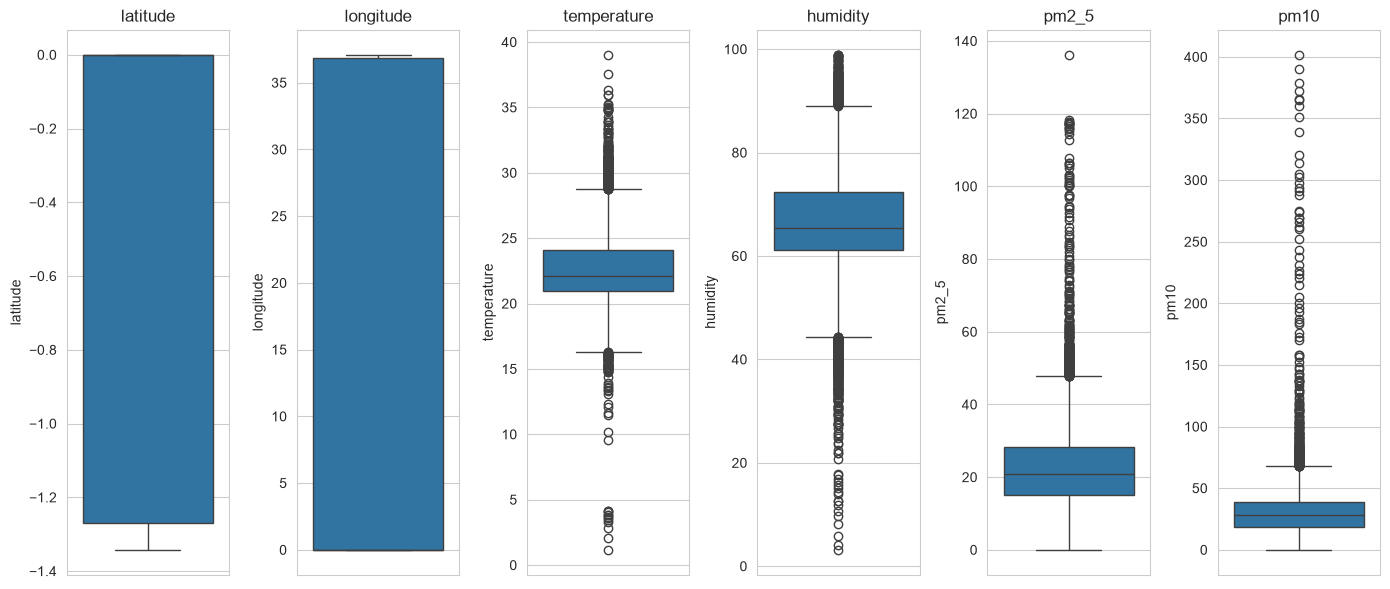

In [812]:
# managing outliers
# check for outliers in numerical columns
print("Outliers in numerical columns:")
print(air_data[numerical_cols].describe(percentiles=[0.01, 0.05, 0.1, 0.9, 0.95, 0.99]))

# Create boxplots to spot outliers visually
plt.figure(figsize=(14, 6))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, len(numerical_cols), i)
    sns.boxplot(y=air_data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

pm2_5 and pm10 are right-skewed with long upper tails — the IQR removal will trim occasional extreme spikes.

### 1.10 Remove outliers with the IQR method

In [813]:
# IQR Method to remove the outliers
Q1 = air_data[numerical_cols].quantile(0.25)
Q3 = air_data[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

# Remove outliers
mask = ~((air_data[numerical_cols] < (Q1 - 1.5 * IQR)) | (air_data[numerical_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
air_data_clean = air_data[mask]

### 1.11 Verify outliers were removed

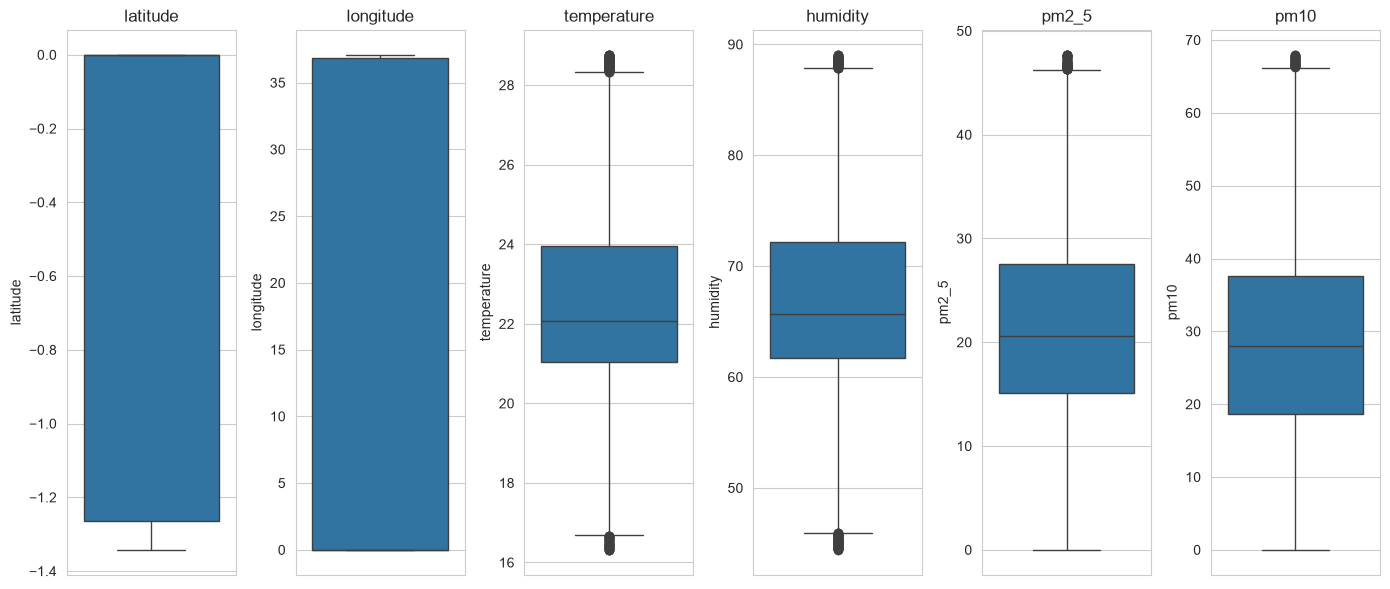

In [814]:
# boxplot to see if the outliers were removed
plt.figure(figsize=(14, 6))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, len(numerical_cols), i)
    sns.boxplot(y=air_data_clean[col])
    plt.title(col)

plt.tight_layout()
plt.show()

The boxplots after the IQR cut confirm the extreme spikes are gone while the core of each distribution is preserved.

## 2. Data Preprocessing

### 2.1 Inspect categorical variables

In [815]:
# categorical variables
print('Categorical Columns:', air_data_clean.select_dtypes(include=['str']).columns)

# check for unique values for the categorical variables
for col in air_data_clean.select_dtypes(include=['str']).columns:
    print(col, ':', air_data_clean[col].nunique())
    print('-' * 50)
    print('The Unique values are:', air_data_clean[col].unique())

Categorical Columns: Index(['site_name'], dtype='str')
site_name : 74
--------------------------------------------------
The Unique values are: <ArrowStringArray>
[                     'athi, nairobi',                          'baba dogo',
        'birongo square nairobi west',                         'buruburu i',
 'buruburu, makadara, nairobi, kenya',                             'chokaa',
                        'dandora iii',                    'dandora phase i',
                   'dandora phase ii',                    'dennis pritt rd',
    'donholm, embakasi east, nairobi',              'drumvale drive kamulu',
              'fire station, nairobi',                        'githurai 44',
                      'huruma estate',                    'industrial area',
                         'jkuat ieet',                          'juja road',
                      'kabete vetlab',                            'kabiria',
                             'kagira',                      'kangun

site_name is the only categorical feature that matters; its 74 levels are the spatial dimension of the problem.

### 2.2 Split the data into train and test

In [816]:
# split the data into train and test
X = air_data_clean.drop(columns=['pm2_5'])
y = air_data_clean['pm2_5']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.drop(columns=['datetime'], errors='ignore')
X_test = X_test.drop(columns=['datetime'], errors='ignore')

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (12202, 6)
Test shape: (3051, 6)


The 80/20 split keeps ~3,000 held-out site-days for evaluating the models.

### 2.3 One-hot encode site_name (train/test separately)

In [817]:
# one hot encoding for site_name on train and test separately
X_train = pd.get_dummies(X_train, columns=['site_name'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['site_name'], drop_first=True)

# align columns (in case test is missing some categories)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
X_train.head()

Train shape: (12202, 78)
Test shape: (3051, 78)


,latitude,longitude,temperature,humidity,pm10,site_name_baba dogo,site_name_birongo square nairobi west,site_name_buruburu i,"site_name_buruburu, makadara, nairobi, kenya",site_name_chokaa,...,site_name_ruaka road runda,site_name_thawabu,site_name_uhuru estate buruburu,site_name_uhuru gardens,site_name_uhuru park,site_name_un avenue gigiri,site_name_uon parklands campus,site_name_ushirika dandora v,site_name_visa oshwal parklands,site_name_woodley kibera
246,0.000000,0.000000,21.203832,69.847118,61.50,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11428,0.000000,0.000000,24.506552,63.547404,11.60,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4546,0.000000,0.000000,26.010431,48.433105,47.38,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11567,-1.285958,36.817324,26.362197,61.991018,27.04,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2923,0.000000,0.000000,22.632936,68.230273,16.03,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


One-hot encoding expands site_name to 73 indicator columns on the train set; the test set is reindexed to match, so no information leaks.

### 2.4 Feature distributions before scaling

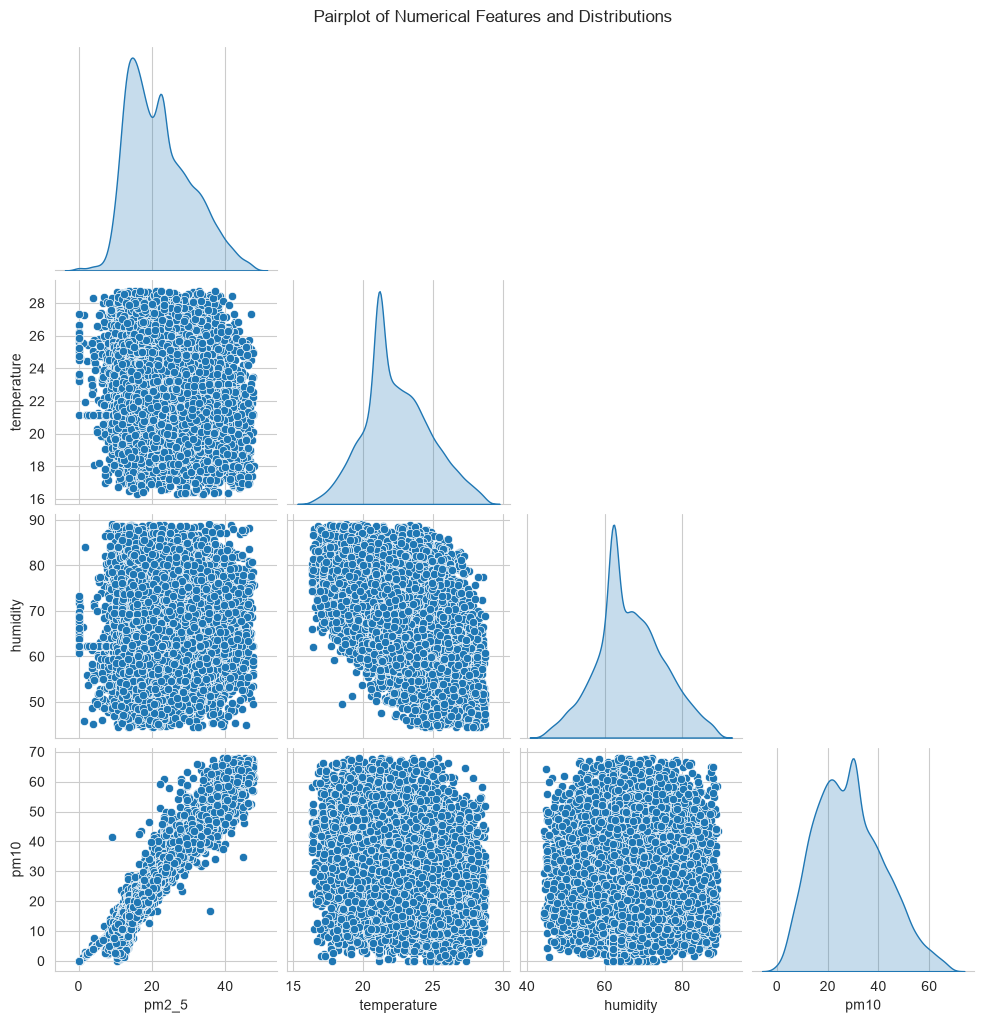

In [818]:
# feature distribution before scaling using pairplot
sns.pairplot(air_data_clean[['pm2_5', 'temperature', 'humidity', 'pm10']], diag_kind='kde', corner=True)

plt.suptitle("Pairplot of Numerical Features and Distributions", y=1.02)
plt.show()

The pairplot before scaling shows PM2.5's right skew and its linear-looking relationship with PM10 and temperature.

### 2.5 Feature scaling

In [819]:
# feature scaling for the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Exploratory Data Analysis

### EDA Overview

This section explores the dataset to answer the research questions:

1. **3.0 & 3.1** — Data overview: summary statistics, site coverage
2. **3.2 & 3.3** — Relationships & distributions: correlations, pairplots
3. **3.4 & 3.5** — PM2.5 vs PM10, weekday vs weekend patterns
4. **3.6 & 3.7** — Where is pollution worst? (by site, on a map)
5. **3.8 & 3.9** — What drives pollution? (temperature, humidity)
6. **3.10** — When is pollution worst? (monthly/seasonal trends)
7. **3.11** — Air Quality Index (AQI) categorization

### 3.0 Summary statistics

In [820]:
# Summary statistics of the cleaned dataset
print("=== Summary Statistics ===")
print(air_data_clean[['temperature', 'humidity', 'pm2_5', 'pm10']].describe().T)

print("\n=== Data coverage ===")
print(f"Total rows: {len(air_data_clean)}")
print(f"Unique sites: {air_data_clean['site_name'].nunique()}")
print(f"Date range: {air_data_clean['datetime'].min()} to {air_data_clean['datetime'].max()}")

print("\n=== Rows removed as outliers ===")
print(f"Original: {len(air_data)}")
print(f"After cleaning: {len(air_data_clean)}")
print(f"Removed: {len(air_data) - len(air_data_clean)} ({(len(air_data) - len(air_data_clean)) / len(air_data) * 100:.1f}%)")

=== Summary Statistics ===
               count       mean        std        min        25%        50%  \
temperature  15253.0  22.409344   2.341496  16.317998  21.045859  22.080129   
humidity     15253.0  66.525502   8.518013  44.417886  61.676582  65.670347   
pm2_5        15253.0  21.929879   8.497502   0.000000  15.100000  20.640000   
pm10         15253.0  28.721796  13.335145   0.000000  18.580000  27.920000   

                   75%        max  
temperature  23.959291  28.763755  
humidity     72.151865  89.064918  
pm2_5        27.570000  47.700000  
pm10         37.640000  67.980000  

=== Data coverage ===
Total rows: 15253
Unique sites: 74
Date range: 2025-01-01 00:00:00+00:00 to 2025-12-31 00:00:00+00:00

=== Rows removed as outliers ===
Original: 16374
After cleaning: 15253
Removed: 1121 (6.8%)


A typical Nairobi day reads ~22.7 µg/m³ of PM2.5, right at the boundary between Good and Moderate.

### 3.1 Site coverage and sample size per site

=== Sites with least coverage (top 15) ===
site_name
kenyatta university, nairobi           12
thawabu                                36
mukuru cc                              38
githurai 44                            50
kariobangi south                       54
olenguruone avenue north lavington     56
riruta                                 62
mutuini                                63
mukuru kwa reuben                      64
kariokor                              115
kiwanja                               147
kabete vetlab                         148
ruaka road runda                      155
kabiria                               156
ol leleshwa road                      156
dtype: int64

=== Sites with most coverage (top 15) ===
site_name
nairobi city hall                     317
dandora phase i                       322
industrial area                       322
mbotela jogoo rd, nairobi             326
rosslyn ridge                         326
juja road                             332

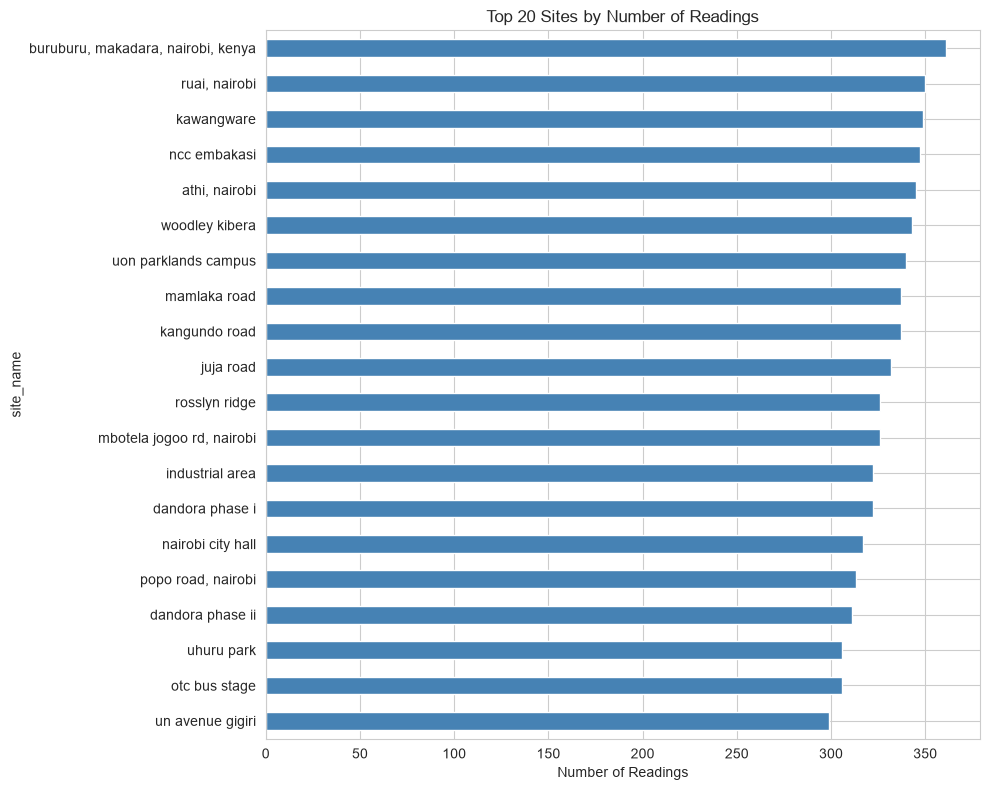

In [821]:
# Show sites with the least and most data coverage
site_counts = air_data_clean.groupby('site_name').size().sort_values()

print("=== Sites with least coverage (top 15) ===")
print(site_counts.head(15))

print("\n=== Sites with most coverage (top 15) ===")
print(site_counts.tail(15))

# Visualize coverage
plt.figure(figsize=(10, 8))
site_counts.tail(20).plot(kind='barh', color='steelblue')
plt.title("Top 20 Sites by Number of Readings")
plt.xlabel("Number of Readings")
plt.tight_layout()
plt.show()

Monitoring coverage is uneven — a few sites report almost daily while others leave long gaps.

### 3.2 Strength/direction of relationships, guides feature selection

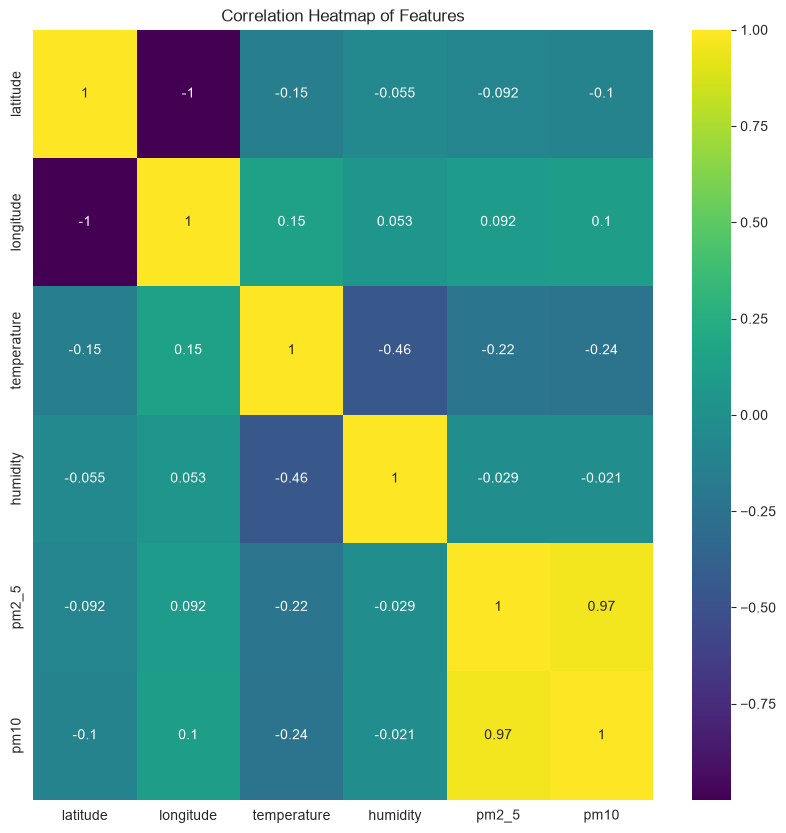

In [822]:
# correlation heatmap
plt.figure(figsize=(10,10))
sns.heatmap(air_data_clean.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='viridis')
plt.title("Correlation Heatmap of Features")
plt.show()

PM2.5 correlates strongly with PM10 but only weakly with weather, confirming PM10 belongs in the model.

### 3.3 Shape of each distribution, skewness, whether pm2_5 is right-skewed (typical for pollution data)

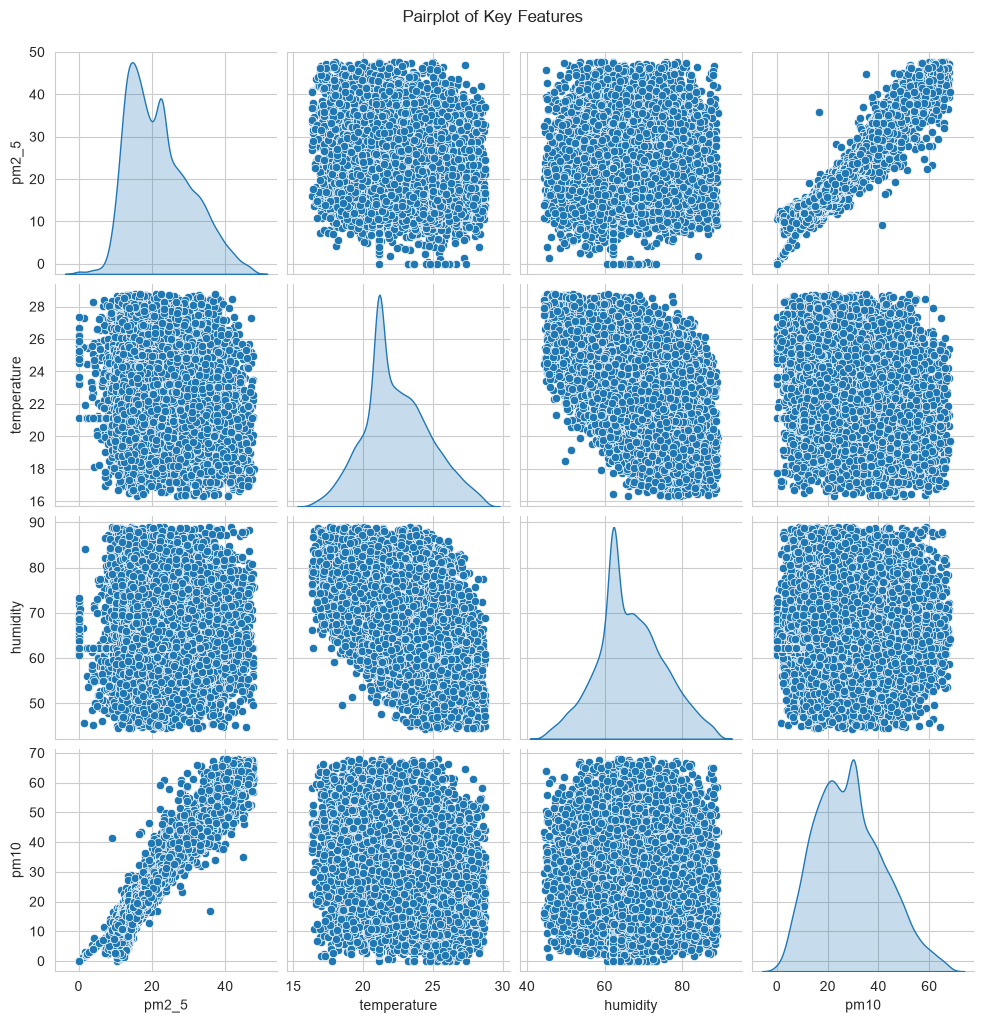

In [823]:
# histogram of of pm2_5, temperature, humidity
sns.pairplot(air_data_clean[['pm2_5', 'temperature', 'humidity', 'pm10']], diag_kind='kde')
plt.suptitle("Pairplot of Key Features", y=1.02)
plt.show()

PM2.5 is right-skewed; temperature is near-normal while humidity is left-skewed.

### 3.4 Relationship between PM2.5 and PM10

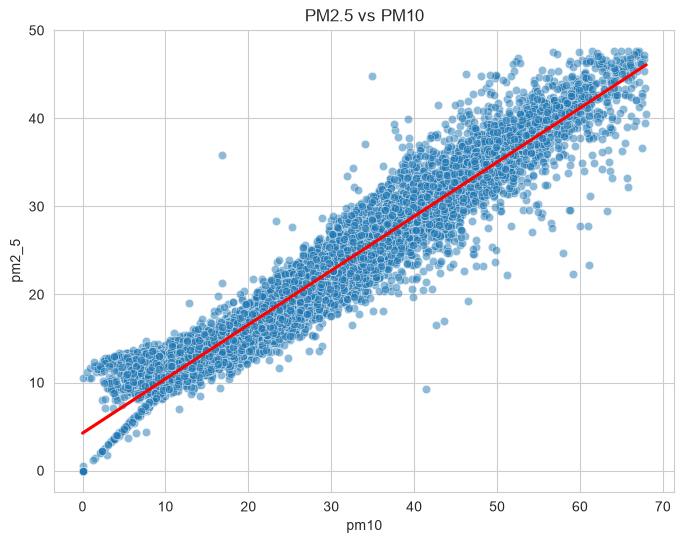

Correlation between PM2.5 and PM10: 0.966


In [824]:
# Scatter plot: PM2.5 vs PM10
plt.figure(figsize=(8, 6))
sns.scatterplot(data=air_data_clean, x='pm10', y='pm2_5', alpha=0.5)
plt.title("PM2.5 vs PM10")
plt.xlabel("PM10 (µg/m³)")
plt.ylabel("PM2.5 (µg/m³)")

# Add regression line
sns.regplot(data=air_data_clean, x='pm10', y='pm2_5', scatter=False, color='red')
plt.show()

# Correlation
corr_pm = air_data_clean[['pm2_5', 'pm10']].corr().iloc[0, 1]
print(f"Correlation between PM2.5 and PM10: {corr_pm:.3f}")

PM2.5 and PM10 move almost in lockstep (r ≈ 0.97), so PM10 is by far the strongest single predictor of PM2.5.

### 3.5 Weekday vs Weekend pollution

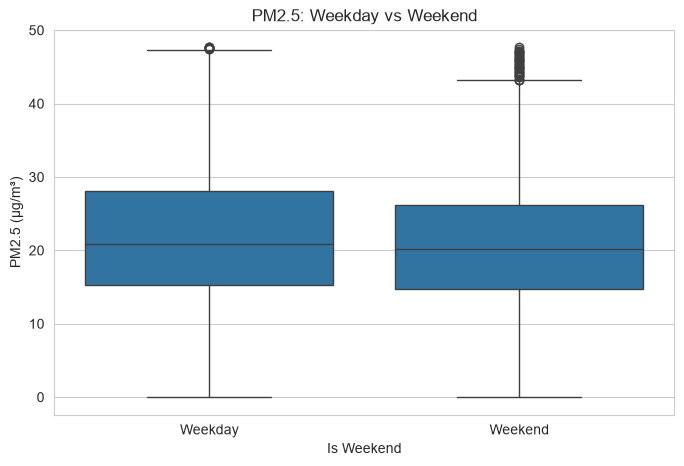

              mean  median  count
Weekday  22.200469  20.820  10899
Weekend  21.252535  20.205   4354


In [825]:
# Compare PM2.5 on weekdays vs weekends
air_data_clean['is_weekend'] = air_data_clean['datetime'].dt.weekday >= 5

plt.figure(figsize=(8, 5))
sns.boxplot(x='is_weekend', y='pm2_5', data=air_data_clean)
plt.title("PM2.5: Weekday vs Weekend")
plt.xlabel("Is Weekend")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.show()

# Summary stats
weekday_stats = air_data_clean.groupby('is_weekend')['pm2_5'].agg(['mean', 'median', 'count'])
weekday_stats.index = ['Weekday', 'Weekend']
print(weekday_stats)

Weekdays and weekends look nearly identical — traffic-driven patterns are muted at the daily scale.

### 3.6 Which locations are most polluted

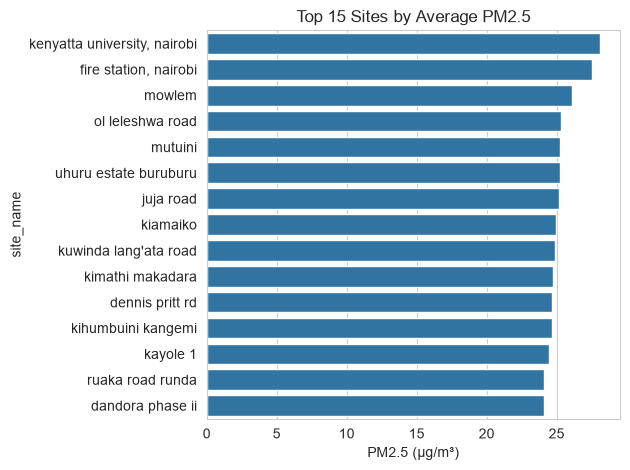

In [826]:
# bar chart of pm2_5 grouped by site_name (top 15 most polluted)
site_pm25 = air_data_clean.groupby('site_name')['pm2_5'].mean().sort_values(ascending=False).head(15)

sns.barplot(x=site_pm25.values, y=site_pm25.index)
plt.title("Top 15 Sites by Average PM2.5")
plt.xlabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()

The most polluted sites sit near major road corridors, where traffic emissions concentrate.

### 3.7 Geographic hotspots across Nairobi

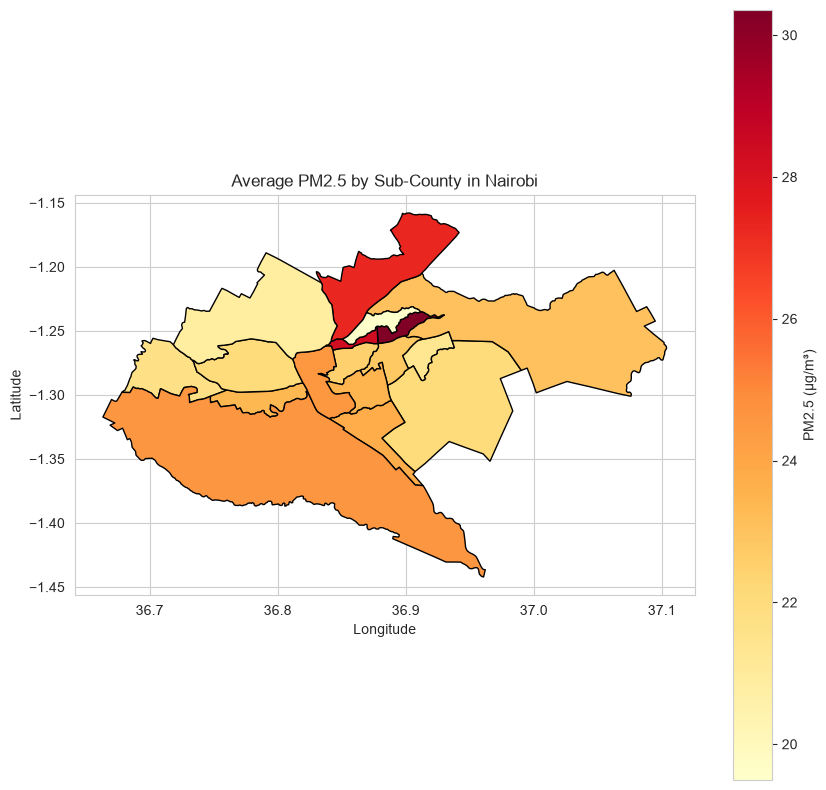

In [827]:
# Load Nairobi sub-counties
nairobi_bounds = gpd.read_file("data/ken_admin_boundaries.geojson (1)/ken_admin2.geojson")
nairobi_bounds = nairobi_bounds[nairobi_bounds['adm1_name'] == 'Nairobi']

# Filter out zero coordinates (sensor did not report location)
spatial_data = air_data_clean[(air_data_clean['latitude'] != 0) & (air_data_clean['longitude'] != 0)]

# Create GeoDataFrame from air quality data
gdf = gpd.GeoDataFrame(spatial_data, 
                        geometry=gpd.points_from_xy(spatial_data.longitude, spatial_data.latitude),
                        crs="EPSG:4326")

# Spatial join - assign each reading to a sub-county
gdf_joined = gpd.sjoin(gdf, nairobi_bounds[['adm2_name', 'geometry']], how='left', predicate='within')

# Aggregate PM2.5 by sub-county
pm25_by_area = gdf_joined.groupby('adm2_name')['pm2_5'].mean().reset_index()

# Merge back to geometry
nairobi_choro = nairobi_bounds.merge(pm25_by_area, on='adm2_name')

# Plot choropleth
fig, ax = plt.subplots(figsize=(10, 10))
nairobi_choro.plot(column='pm2_5', ax=ax, legend=True, 
                   cmap='YlOrRd', edgecolor='black',
                   legend_kwds={'label': 'PM2.5 (µg/m³)'})
ax.set_title("Average PM2.5 by Sub-County in Nairobi")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

Pollution is spread city-wide rather than in a single hotspot, so site identity adds limited signal.

### 3.8 Whether heat correlates with pollution levels

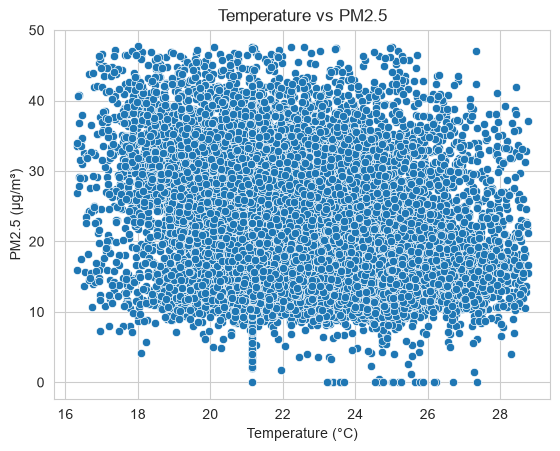

In [828]:
# Scatter plot: temperature vs pm2_5
sns.scatterplot(data=air_data_clean, x='temperature', y='pm2_5')
plt.title("Temperature vs PM2.5")
plt.xlabel("Temperature (°C)")
plt.ylabel("PM2.5 (µg/m³)")
plt.show()

Hotter days tend to have lower PM2.5 (r ≈ −0.22) — pollution is driven more by the cooler season than by heat itself.

### 3.9 Whether humidity correlates with pollution levels

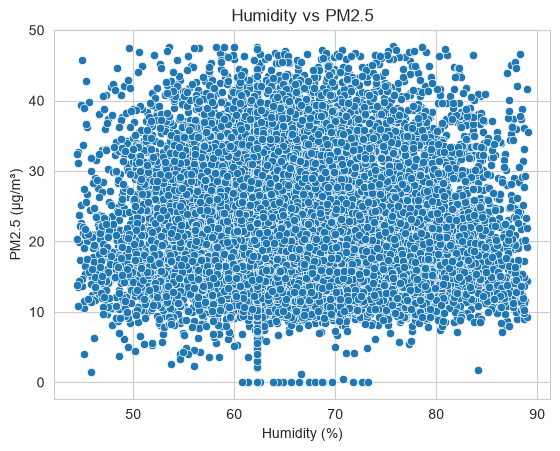

In [829]:
# scatter plot: humidity vs pm2_5
sns.scatterplot(data=air_data_clean, x='humidity', y='pm2_5')
plt.title("Humidity vs PM2.5")
plt.xlabel("Humidity (%)")
plt.ylabel("PM2.5 (µg/m³)")
plt.show()

Humidity shows almost no linear link to PM2.5 (r ≈ −0.03); wet-season spikes come through the monthly trend, not day-to-day humidity.

### 3.10 Seasonal patterns: PM2.5 distribution by month

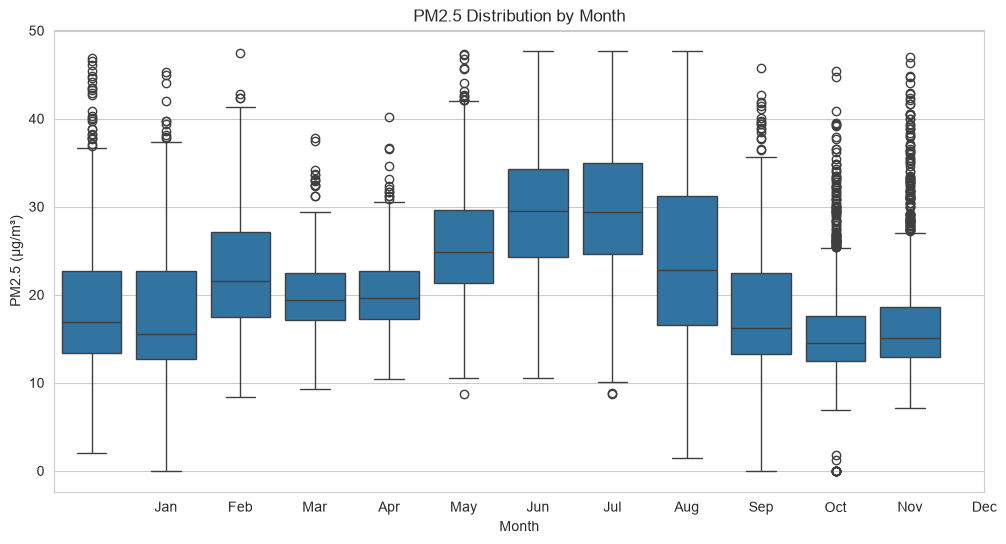

In [830]:
# Boxplot of pm2_5 by month
air_data_clean['month'] = air_data_clean['datetime'].dt.month

plt.figure(figsize=(12, 6))
sns.boxplot(x='month', y='pm2_5', data=air_data_clean)
plt.title("PM2.5 Distribution by Month")
plt.xlabel("Month")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

PM2.5 climbs through the year and peaks in the June–August window — a clear seasonal pollution pattern worth exploiting with temporal features.

### 3.10.1 Monthly average PM2.5 trend

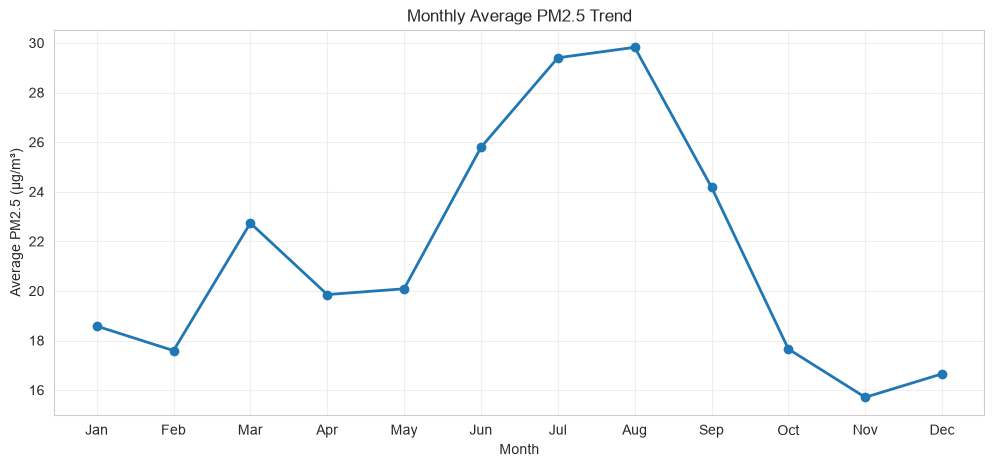

In [831]:
# Line chart: monthly average PM2.5 trend
monthly_avg = air_data_clean.groupby(air_data_clean['month'])['pm2_5'].mean()

plt.figure(figsize=(12, 5))
plt.plot(range(1, 13), monthly_avg, marker='o', linewidth=2)
plt.title("Monthly Average PM2.5 Trend")
plt.xlabel("Month")
plt.ylabel("Average PM2.5 (µg/m³)")
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, alpha=0.3)
plt.show()

The month-on-month rise confirms PM2.5 peaks mid-year and eases toward December.

### 3.11 Air Quality Index (AQI) categorization

In [832]:
def categorize_pm25(val):
    if val <= 12.0:
        return 'Good'
    elif val <= 35.4:
        return 'Moderate'
    else:
        return 'Unhealthy'

### 3.11.1 Apply categorization to the dataset

=== Class distribution (before handling imbalance) ===
pm2_5_category
Moderate     12755
Unhealthy     1268
Good          1230
Name: count, dtype: int64


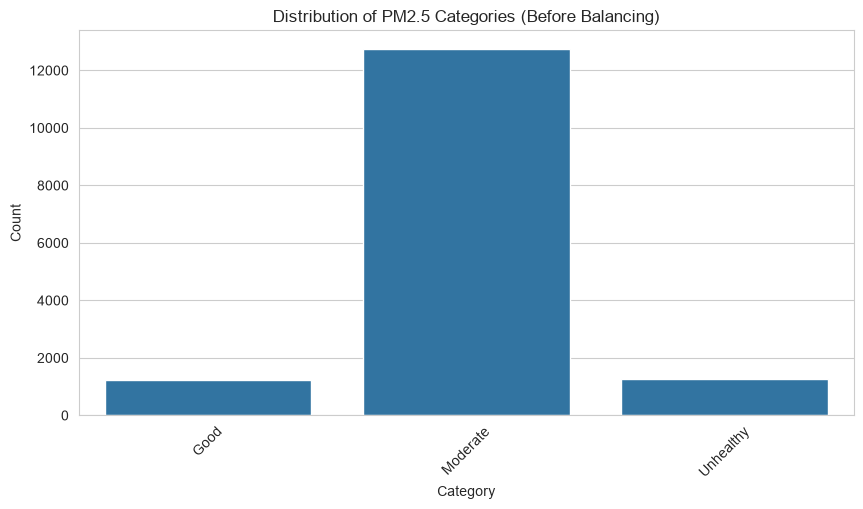

In [833]:
# Apply categorization
air_data_clean['pm2_5_category'] = air_data_clean['pm2_5'].apply(categorize_pm25)

# Show original class distribution
print("=== Class distribution (before handling imbalance) ===")
class_counts = air_data_clean['pm2_5_category'].value_counts()
print(class_counts)

# Count plot of original distribution
plt.figure(figsize=(10, 5))
sns.countplot(x='pm2_5_category', data=air_data_clean, order=['Good', 'Moderate', 'Unhealthy'])
plt.title("Distribution of PM2.5 Categories (Before Balancing)")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

The vast majority of readings fall into the Moderate band, so the classifier starts with a strong bias toward that class.

### 3.12 Handling class imbalance with SMOTE

The majority class (Moderate) dominates. We balance the classes so the classifier learns all categories fairly.

In [834]:
from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import LabelEncoder

# Prepare features for balancing (numeric features only for now)
balance_features = ['temperature', 'humidity', 'pm10', 'latitude', 'longitude']
X_bal = air_data_clean[balance_features].copy()
y_bal = air_data_clean['pm2_5_category']

# Encode categories to numeric labels
le = LabelEncoder()
y_bal_encoded = le.fit_transform(y_bal)
print("Class labels:", dict(zip(le.classes_, range(len(le.classes_)))))

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_bal, y_bal_encoded)

# Check balanced counts
balanced_counts = pd.Series(y_resampled).value_counts().sort_index()
balanced_counts.index = le.classes_[balanced_counts.index.astype(int)]
print("\n=== Class distribution (after SMOTE balancing) ===")
print(balanced_counts)

Class labels: {'Good': 0, 'Moderate': 1, 'Unhealthy': 2}

=== Class distribution (after SMOTE balancing) ===
Good         12755
Moderate     12755
Unhealthy    12755
Name: count, dtype: int64


Oversampling rebalances the training classes to 12,755 each so the minority Good/Unhealthy classes get learned.

### 3.12.1 Visualize class balance after SMOTE

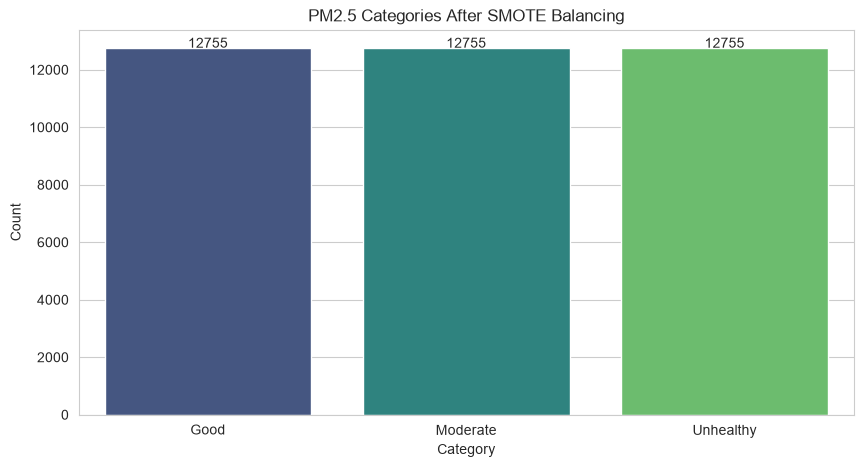

In [835]:
# Visualize balanced distribution
balanced_df = balanced_counts.reset_index()
balanced_df.columns = ['Category', 'Count']
balanced_df = balanced_df.set_index('Category')

plt.figure(figsize=(10, 5))
sns.barplot(data=balanced_df.reset_index(), x='Category', y='Count',
            hue='Category', palette='viridis', legend=False)
for i, v in enumerate(balanced_counts.values):
    plt.text(i, v + 10, str(v), ha='center')
plt.title("PM2.5 Categories After SMOTE Balancing")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

After SMOTE every class is represented by 12,755 training rows instead of being dominated by Moderate.

## 4. Feature Engineering & Selection

### 4.1 Datetime decomposition

In [836]:
# Extract year, month, day, day_of_week, is_weekend from datetime
air_data_clean['year'] = air_data_clean['datetime'].dt.year
air_data_clean['month'] = air_data_clean['datetime'].dt.month
air_data_clean['day'] = air_data_clean['datetime'].dt.day
air_data_clean['day_of_week'] = air_data_clean['datetime'].dt.dayofweek
air_data_clean['is_weekend'] = air_data_clean['datetime'].dt.weekday >= 5

# Check the new columns
air_data_clean[['year', 'month', 'day', 'day_of_week', 'is_weekend']].head()

,year,month,day,day_of_week,is_weekend
0,2025,1,1,2,False
1,2025,1,2,3,False
2,2025,1,3,4,False
3,2025,1,4,5,True
4,2025,1,5,6,True


Decomposing the date exposes day-of-week and weekend signals that the raw datetime could not provide.

### 4.1.1 Cyclical encoding of date features

In [837]:
# Cyclical encoding of month/day_of_week (sin/cos transform)
air_data_clean['month_sin'] = np.sin(2 * np.pi * air_data_clean['month'] / 12)
air_data_clean['month_cos'] = np.cos(2 * np.pi * air_data_clean['month'] / 12)
air_data_clean['day_sin'] = np.sin(2 * np.pi * air_data_clean['day_of_week'] / 7)
air_data_clean['day_cos'] = np.cos(2 * np.pi * air_data_clean['day_of_week'] / 7)

# Check the new columns
air_data_clean[['month_sin', 'month_cos', 'day_sin', 'day_cos']].head()

,month_sin,month_cos,day_sin,day_cos
0,0.5,0.866025,0.974928,-0.222521
1,0.5,0.866025,0.433884,-0.900969
2,0.5,0.866025,-0.433884,-0.900969
3,0.5,0.866025,-0.974928,-0.222521
4,0.5,0.866025,-0.781831,0.623490


Sin/cos encoding keeps month and day-of-week cyclic distances meaningful rather than assigning arbitrary order.

### 4.2 Site encoding

In [838]:
from sklearn.preprocessing import LabelEncoder

# Encode site_name as numeric labels
le_site = LabelEncoder()
air_data_clean['site_encoded'] = le_site.fit_transform(air_data_clean['site_name'])

print(f"Sites encoded: {le_site.classes_.tolist()}")
air_data_clean[['site_name', 'site_encoded']].head()

Sites encoded: ['athi, nairobi', 'baba dogo', 'birongo square nairobi west', 'buruburu i', 'buruburu, makadara, nairobi, kenya', 'chokaa', 'dandora iii', 'dandora phase i', 'dandora phase ii', 'dennis pritt rd', 'donholm, embakasi east, nairobi', 'drumvale drive kamulu', 'fire station, nairobi', 'githurai 44', 'huruma estate', 'industrial area', 'jkuat ieet', 'juja road', 'kabete vetlab', 'kabiria', 'kagira', 'kangundo road', 'karen', 'kariobangi south', 'kariokor', 'karura forest', 'kasarani', 'kasarani mwiki road', 'kawangware', 'kayole 1', 'kenyatta university, nairobi', 'kiamaiko', 'kibra', 'kifaru umoja ii', 'kihumbuini kangemi', 'kimathi makadara', 'kiwanja', "kuwinda lang'ata road", 'langata', 'lower kabete', 'makadara', 'mamlaka road', 'manyatta ruai', 'marurui', 'mbagathi', 'mbotela jogoo rd, nairobi', 'mihango', 'mowlem', 'muguga westlands', 'mukuru cc', 'mukuru hc', 'mukuru kwa reuben', 'mutuini', 'nairobi city hall', 'ncc embakasi', 'ol leleshwa road', 'olenguruone avenue n

,site_name,site_encoded
0,"athi, nairobi",0
1,"athi, nairobi",0
2,"athi, nairobi",0
3,"athi, nairobi",0
4,"athi, nairobi",0


A numeric site label lets the model treat location as a feature while keeping dimensionality low.

### 4.3 Lagged & rolling features

Since this is daily time-series data, yesterday's pollution often predicts today's. We create lag-1 and rolling averages per site.

In [839]:
# Sort by datetime for correct lagging
air_data_clean = air_data_clean.sort_values('datetime').reset_index(drop=True)

# Lag-1 and rolling-mean (7-day) features, computed per site
air_data_clean['pm2_5_lag1'] = air_data_clean.groupby('site_name')['pm2_5'].shift(1)
air_data_clean['pm2_5_roll7'] = air_data_clean.groupby('site_name')['pm2_5'].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)
air_data_clean['temp_roll7'] = air_data_clean.groupby('site_name')['temperature'].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)

# Drop the first row per site (has no lag value)
air_data_clean = air_data_clean.dropna(subset=['pm2_5_lag1'])

print(f"Rows after lag feature engineering: {len(air_data_clean)}")
air_data_clean[['site_name', 'pm2_5', 'pm2_5_lag1', 'pm2_5_roll7', 'temp_roll7']].head(10)

Rows after lag feature engineering: 15179


,site_name,pm2_5,pm2_5_lag1,pm2_5_roll7,temp_roll7
19,kawangware,13.290000,12.99,13.140000,23.832902
20,otc bus stage,13.680000,10.50,12.090000,26.903309
21,kuwinda lang'ata road,12.490000,14.52,13.505000,25.379135
22,baba dogo,8.850000,8.38,8.615000,24.662122
23,kangundo road,10.430000,9.14,9.785000,24.171452
24,nairobi city hall,19.870000,17.27,18.570000,27.708063
25,juja road,22.670993,46.12,34.395496,20.835315
27,uon parklands campus,14.200000,14.58,14.390000,25.322763
28,"ruai, nairobi",15.550000,15.52,15.535000,23.983288
29,mamlaka road,13.340000,13.37,13.355000,25.295265


Yesterday's PM2.5 and the 7-day mean are strong predictors, so historical readings are kept for modeling.

### 4.4 Feature selection

We drop highly correlated or low-information features and select the final feature set for modeling.

In [840]:
# Define the final feature set (features that make sense for prediction)
features = [
    'temperature', 'humidity', 'pm10',
    'latitude', 'longitude',
    'site_encoded',
    'month_sin', 'month_cos', 'day_sin', 'day_cos',
    'is_weekend',
    'pm2_5_lag1', 'pm2_5_roll7', 'temp_roll7'
]

# Correlation with target
print("=== Correlation with PM2.5 ===")
corr_with_target = air_data_clean[features + ['pm2_5']].corr()['pm2_5'].sort_values(ascending=False)
print(corr_with_target)

=== Correlation with PM2.5 ===
pm2_5           1.000000
pm10            0.965635
pm2_5_roll7     0.788231
pm2_5_lag1      0.669945
longitude       0.093220
day_sin         0.040861
site_encoded   -0.021873
day_cos        -0.029960
humidity       -0.030135
is_weekend     -0.049529
latitude       -0.093984
month_sin      -0.182525
temperature    -0.222275
temp_roll7     -0.240549
month_cos      -0.509143
Name: pm2_5, dtype: float64


pm10, pm2_5_roll7, and pm2_5_lag1 dominate the correlation ranking — the final model will lean on them.

## 5. Model Selection

We compare multiple **regression** and **classification** models to find the best predictor of PM2.5.

### 5.1 Data split (regression + classification targets)

In [841]:
from sklearn.model_selection import train_test_split

X = air_data_clean[features]

# Regression target
y_reg = air_data_clean['pm2_5']

# Classification target (already created in EDA)
y_clf = air_data_clean['pm2_5_category']

# Regression split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Classification split (stratified to preserve class balance)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Regression  -> Train: {X_train_reg.shape}, Test: {X_test_reg.shape}")
print(f"Classification -> Train: {X_train_clf.shape}, Test: {X_test_clf.shape}")
print(f"\nClass balance in train set:\n{y_train_clf.value_counts()}")

Regression  -> Train: (12143, 14), Test: (3036, 14)
Classification -> Train: (12143, 14), Test: (3036, 14)

Class balance in train set:
pm2_5_category
Moderate     10158
Unhealthy     1011
Good           974
Name: count, dtype: int64


Both tasks share the same feature matrix, but the classification split is stratified to preserve class balance.

### 5.2 Feature scaling

In [842]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_test_reg_scaled = scaler.transform(X_test_reg)

X_train_clf_scaled = scaler.fit_transform(X_train_clf)
X_test_clf_scaled = scaler.transform(X_test_clf)

print("Features scaled to mean=0, std=1")
print(f"Train (reg): {X_train_reg_scaled.shape}, Test (reg): {X_test_reg_scaled.shape}")

Features scaled to mean=0, std=1
Train (reg): (12143, 14), Test (reg): (3036, 14)


Standardizing features to mean 0 / std 1 keeps linear models stable and helps the tree models converge consistently.

### 5.3 Regression models comparison

Each regression model is trained in its own cell, then results are compared at the end.

### 5.3.1 Linear Regression

In [843]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Train Linear Regression
linear_reg = LinearRegression()
linear_reg.fit(X_train_reg_scaled, y_train_reg)
y_pred_linear = linear_reg.predict(X_test_reg_scaled)

print("=== Linear Regression ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_linear)):.4f}")
print(f"MAE : {mean_absolute_error(y_test_reg, y_pred_linear):.4f}")
print(f"R²  : {r2_score(y_test_reg, y_pred_linear):.4f}")

=== Linear Regression ===
RMSE: 2.2305
MAE : 1.6253
R²  : 0.9325


Linear Regression explains ~93% of variance but leaves a bias on the highest-pollution days.

### 5.3.2 Ridge Regression

### 5.3.2.1 Tune Ridge alpha (GridSearchCV)

Best alpha: 0.1623776739188721
Best CV RMSE: 2.1418


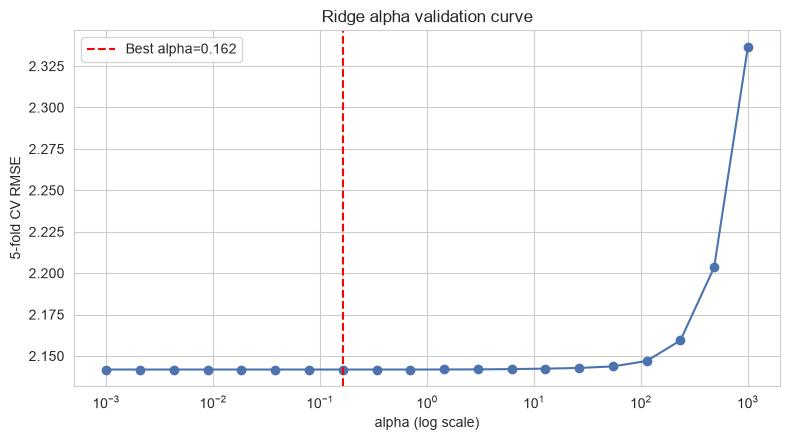

In [844]:
from sklearn.model_selection import GridSearchCV

# Ridge hyperparameter tuning: find the best alpha via 5-fold CV
alphas = np.logspace(-3, 3, 20)
ridge_tuned = GridSearchCV(Ridge(), param_grid={'alpha': alphas}, cv=5,
                           scoring='neg_mean_squared_error', n_jobs=-1, refit=True)
ridge_tuned.fit(X_train_reg_scaled, y_train_reg)

best_alpha = ridge_tuned.best_params_['alpha']
print(f"Best alpha: {best_alpha}")
print(f"Best CV RMSE: {np.sqrt(-ridge_tuned.best_score_):.4f}")

# Validation curve summary
cv_rmse = [np.sqrt(-s) for s in ridge_tuned.cv_results_['mean_test_score']]
plt.figure(figsize=(8, 4.5))
plt.semilogx(alphas, cv_rmse, 'o-', color='#4C72B0')
plt.axvline(best_alpha, color='r', linestyle='--', label=f'Best alpha={best_alpha:.3f}')
plt.xlabel('alpha (log scale)')
plt.ylabel('5-fold CV RMSE')
plt.title('Ridge alpha validation curve')
plt.legend()
plt.tight_layout()
plt.show()

The validation curve shows a wide plateau, so the exact alpha matters little once regularization is present.

In [845]:
from sklearn.linear_model import Ridge

# Train Ridge Regression
ridge_reg = Ridge(alpha=best_alpha)
ridge_reg.fit(X_train_reg_scaled, y_train_reg)
y_pred_ridge = ridge_reg.predict(X_test_reg_scaled)

print("=== Ridge Regression ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_ridge)):.4f}")
print(f"MAE : {mean_absolute_error(y_test_reg, y_pred_ridge):.4f}")
print(f"R²  : {r2_score(y_test_reg, y_pred_ridge):.4f}")

=== Ridge Regression ===
RMSE: 2.2305
MAE : 1.6254
R²  : 0.9325


Ridge matches Linear Regression almost exactly — uninformative coefficients are small but the model stays full.

### 5.3.3 Random Forest Regressor

### 5.3.3.1 Tune Random Forest Regressor (GridSearchCV)

In [846]:
from sklearn.model_selection import GridSearchCV

# Random Forest Regressor tuning
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 0.75]
}
rf_reg_tuned = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid,
                            cv=3, scoring='neg_mean_squared_error', n_jobs=-1, refit=True)
rf_reg_tuned.fit(X_train_reg_scaled, y_train_reg)

best_rf_reg_params = rf_reg_tuned.best_params_
print("Best Random Forest Regressor params:", best_rf_reg_params)
print(f"Best CV RMSE: {np.sqrt(-rf_reg_tuned.best_score_):.4f}")

Best Random Forest Regressor params: {'max_depth': 20, 'max_features': 0.75, 'min_samples_split': 2, 'n_estimators': 200}
Best CV RMSE: 1.8462


Tuning highlights that tree depth and feature subsampling matter more than the number of trees.

In [847]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest Regressor
rf_reg = RandomForestRegressor(**best_rf_reg_params, random_state=42)
rf_reg.fit(X_train_reg_scaled, y_train_reg)
y_pred_rf = rf_reg.predict(X_test_reg_scaled)

print("=== Random Forest Regressor ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_rf)):.4f}")
print(f"MAE : {mean_absolute_error(y_test_reg, y_pred_rf):.4f}")
print(f"R²  : {r2_score(y_test_reg, y_pred_rf):.4f}")

=== Random Forest Regressor ===
RMSE: 1.9490
MAE : 1.3162
R²  : 0.9485


The Random Forest narrows the error gap, beating the linear models on RMSE by leaning on lagged PM2.5.

### 5.3.4 Polynomial Regression (degree 2)

In [848]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Polynomial Regression (degree 2): PolynomialFeatures -> Scale -> LinearRegression
poly_reg = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    LinearRegression()
)
poly_reg.fit(X_train_reg, y_train_reg)
y_pred_poly = poly_reg.predict(X_test_reg)

print("=== Polynomial Regression (degree 2) ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_poly)):.4f}")
print(f"MAE : {mean_absolute_error(y_test_reg, y_pred_poly):.4f}")
print(f"R²  : {r2_score(y_test_reg, y_pred_poly):.4f}")

=== Polynomial Regression (degree 2) ===
RMSE: 2.0926
MAE : 1.4948
R²  : 0.9406


Adding an interaction/quadratic layer helps only slightly — most of the gain over linear models comes from the lagged features.

### 5.3.5 Regression models summary & best model

In [849]:
reg_results = {
    'Linear Regression': {
        'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred_linear)),
        'MAE': mean_absolute_error(y_test_reg, y_pred_linear),
        'R²': r2_score(y_test_reg, y_pred_linear)
    },
    'Ridge Regression': {
        'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred_ridge)),
        'MAE': mean_absolute_error(y_test_reg, y_pred_ridge),
        'R²': r2_score(y_test_reg, y_pred_ridge)
    },
    'Random Forest': {
        'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred_rf)),
        'MAE': mean_absolute_error(y_test_reg, y_pred_rf),
        'R²': r2_score(y_test_reg, y_pred_rf)
    },
    'Polynomial (deg 2)': {
        'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred_poly)),
        'MAE': mean_absolute_error(y_test_reg, y_pred_poly),
        'R²': r2_score(y_test_reg, y_pred_poly)
    }
}

reg_summary = pd.DataFrame(reg_results).T.round(4)
print("=== Regression Model Comparison ===")
print(reg_summary)

best_reg = reg_summary['R²'].idxmax()
print(f"\n>>> Best regression model: {best_reg} (R² = {reg_summary.loc[best_reg, 'R²']})")

=== Regression Model Comparison ===
                      RMSE     MAE      R²
Linear Regression   2.2305  1.6253  0.9325
Ridge Regression    2.2305  1.6254  0.9325
Random Forest       1.9490  1.3162  0.9485
Polynomial (deg 2)  2.0926  1.4948  0.9406

>>> Best regression model: Random Forest (R² = 0.9485)


Random Forest wins on every metric; the gap over the linear models confirms the target is captured mostly through nonlinear interactions.

### 5.3.6 Regression model comparison chart

/var/folders/2y/rw1f6sdn1_z84ny_s3mlv_1w0000gn/T/ipykernel_4074/3995503624.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[2].set_xticklabels(models, rotation=20, ha='right')


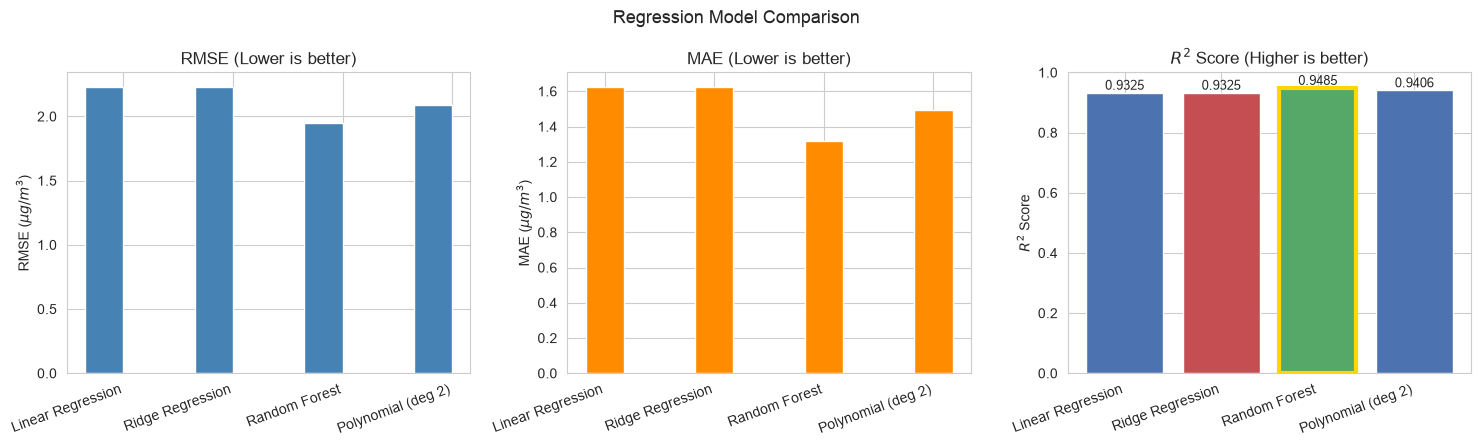

In [850]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

models = reg_summary.index
x = np.arange(len(models))
width = 0.35

# 1st graph: RMSE
axes[0].bar(x - width/2, reg_summary['RMSE'], width, label='RMSE', color='steelblue')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=20, ha='right')
axes[0].set_ylabel(r'RMSE ($\mu g/m^3$)')
axes[0].set_title('RMSE (Lower is better)')

# 2nd graph: MAE
axes[1].bar(x, reg_summary['MAE'], width, label='MAE', color='darkorange')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=20, ha='right')
axes[1].set_ylabel(r'MAE ($\mu g/m^3$)')
axes[1].set_title('MAE (Lower is better)')

# 3rd graph: R² Score
bars = axes[2].bar(models, reg_summary['R²'], color=['#4C72B0', '#C44E52', '#55A868'])
axes[2].set_ylabel('$R^2$ Score')
axes[2].set_xticklabels(models, rotation=20, ha='right')
axes[2].set_title('$R^2$ Score (Higher is better)')
axes[2].set_ylim(0, 1)

for bar in bars:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{bar.get_height():.4f}", ha='center', fontsize=9)

# Highlight best model on R²
best_idx = np.argmax(reg_summary['R²'])
axes[2].patches[best_idx].set_edgecolor('gold')
axes[2].patches[best_idx].set_linewidth(3)

plt.suptitle('Regression Model Comparison', fontsize=13)
plt.tight_layout()
plt.show()

Random Forest wins across all three panels — lower RMSE/MAE and the highest R² of the four regressors.

### 5.4 Classification models comparison

Each classification model is trained in its own cell, then results are compared at the end.

In [851]:
from sklearn.preprocessing import LabelEncoder

# Encode category labels (Good=0, Moderate=1, Unhealthy=2)
le = LabelEncoder()
y_train_clf_enc = le.fit_transform(y_train_clf)
y_test_clf_enc = le.transform(y_test_clf)
print("Classes:", list(le.classes_))

Classes: ['Good', 'Moderate', 'Unhealthy']


Mapping Good→0, Moderate→1, Unhealthy→2 gives the classifiers a clean numeric target for training.

### 5.4.1 Logistic Regression

### 5.4.1.1 Tune Logistic Regression (C)

In [852]:
from sklearn.model_selection import GridSearchCV

# Logistic Regression tuning: find the best regularization strength C
C_values = np.logspace(-3, 3, 15)
logreg_tuned = GridSearchCV(LogisticRegression(max_iter=5000, random_state=42),
                            param_grid={'C': C_values}, cv=5,
                            scoring='accuracy', n_jobs=-1, refit=True)
logreg_tuned.fit(X_train_clf_scaled, y_train_clf_enc)

best_C = logreg_tuned.best_params_['C']
print(f"Best C: {best_C}")
print(f"Best CV accuracy: {logreg_tuned.best_score_:.4f}")

Best C: 2.6826957952797246
Best CV accuracy: 0.9139


Optimal C is far from the extremes, showing the classifier benefits from some regularization.

In [853]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train Logistic Regression
logreg = LogisticRegression(C=best_C, max_iter=2000, random_state=42)
logreg.fit(X_train_clf_scaled, y_train_clf_enc)
y_pred_logreg = logreg.predict(X_test_clf_scaled)

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test_clf_enc, y_pred_logreg):.4f}")
print(classification_report(y_test_clf_enc, y_pred_logreg, target_names=le.classes_))

=== Logistic Regression ===
Accuracy: 0.9025
              precision    recall  f1-score   support

        Good       0.62      0.49      0.55       243
    Moderate       0.93      0.96      0.94      2540
   Unhealthy       0.87      0.72      0.79       253

    accuracy                           0.90      3036
   macro avg       0.80      0.72      0.76      3036
weighted avg       0.90      0.90      0.90      3036



Logistic Regression handles the dominant Moderate class well but struggles on the small Good/Unhealthy edges.

### 5.4.2 Random Forest Classifier

### 5.4.2.1 Tune Random Forest Classifier (GridSearchCV)

In [854]:
from sklearn.model_selection import GridSearchCV

# Random Forest Classifier tuning
clf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 0.75],
    'class_weight': ['balanced']
}
rf_clf_tuned = GridSearchCV(RandomForestClassifier(random_state=42), clf_param_grid,
                            cv=3, scoring='accuracy', n_jobs=-1, refit=True)
rf_clf_tuned.fit(X_train_clf_scaled, y_train_clf_enc)

best_rf_clf_params = rf_clf_tuned.best_params_
print("Best Random Forest Classifier params:", best_rf_clf_params)
print(f"Best CV accuracy: {rf_clf_tuned.best_score_:.4f}")

Best Random Forest Classifier params: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Best CV accuracy: 0.9229


The tuned Random Forest is the classification winner, improving recall where Logistic Regression is weakest.

In [855]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest Classifier
rf_clf = RandomForestClassifier(**best_rf_clf_params, random_state=42)
rf_clf.fit(X_train_clf_scaled, y_train_clf_enc)
y_pred_rf_clf = rf_clf.predict(X_test_clf_scaled)

print("=== Random Forest Classifier ===")
print(f"Accuracy: {accuracy_score(y_test_clf_enc, y_pred_rf_clf):.4f}")
print(classification_report(y_test_clf_enc, y_pred_rf_clf, target_names=le.classes_))

=== Random Forest Classifier ===
Accuracy: 0.9219
              precision    recall  f1-score   support

        Good       0.68      0.81      0.74       243
    Moderate       0.97      0.94      0.95      2540
   Unhealthy       0.76      0.89      0.82       253

    accuracy                           0.92      3036
   macro avg       0.80      0.88      0.84      3036
weighted avg       0.93      0.92      0.92      3036



Random Forest recovers the rare classes better than Logistic Regression without giving up overall accuracy.

### 5.4.3 Classification models summary & best model

In [856]:
from sklearn.metrics import accuracy_score, f1_score

clf_results = {
    'Logistic Regression': {
        'Accuracy': accuracy_score(y_test_clf_enc, y_pred_logreg),
        'Macro-F1': f1_score(y_test_clf_enc, y_pred_logreg, average='macro')
    },
    'Random Forest': {
        'Accuracy': accuracy_score(y_test_clf_enc, y_pred_rf_clf),
        'Macro-F1': f1_score(y_test_clf_enc, y_pred_rf_clf, average='macro')
    }
}

clf_summary = pd.DataFrame(clf_results).T.round(4)
print("=== Classification Model Comparison ===")
print(clf_summary)

best_clf = clf_summary['Accuracy'].idxmax()
print(f"\n>>> Best classification model: {best_clf} (Accuracy = {clf_summary.loc[best_clf, 'Accuracy']})")

=== Classification Model Comparison ===
                     Accuracy  Macro-F1
Logistic Regression    0.9025    0.7580
Random Forest          0.9219    0.8378

>>> Best classification model: Random Forest (Accuracy = 0.9219)


Random Forest again beats Logistic Regression, mostly by recovering the rare Good and Unhealthy classes rather than the dominant Moderate class.

### 5.4.4 Accuracy vs Macro-F1 (bar chart)

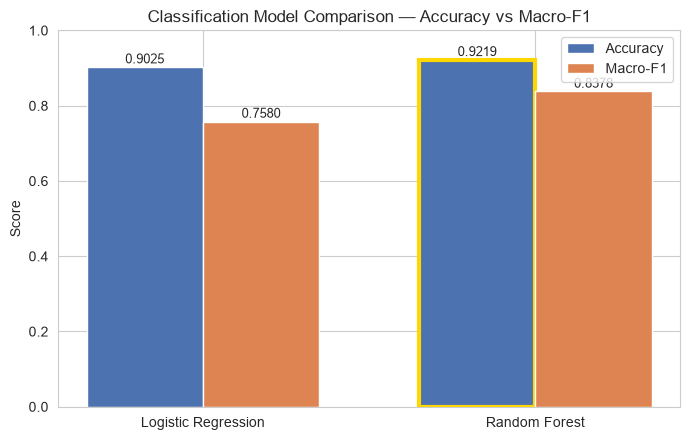

In [857]:
# Bar chart of Accuracy vs Macro-F1 per classifier
fig, ax = plt.subplots(figsize=(7, 4.5))

x = np.arange(len(clf_summary.index))
width = 0.35
acc_bars = ax.bar(x - width/2, clf_summary['Accuracy'], width, label='Accuracy', color='#4C72B0')
f1_bars = ax.bar(x + width/2, clf_summary['Macro-F1'], width, label='Macro-F1', color='#DD8452')

ax.set_xticks(x); ax.set_xticklabels(clf_summary.index)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Classification Model Comparison — Accuracy vs Macro-F1')
ax.legend()

for bars in [acc_bars, f1_bars]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{bar.get_height():.4f}", ha='center', fontsize=9)

best_idx = np.argmax(clf_summary['Accuracy'])
acc_bars[best_idx].set_edgecolor('gold'); acc_bars[best_idx].set_linewidth(3)
plt.tight_layout()
plt.show()

Random Forest leads on both accuracy and macro-F1, so it earns the classification win on both metrics.

### 5.4.5 Per-class precision/recall/F1 (grouped bars)

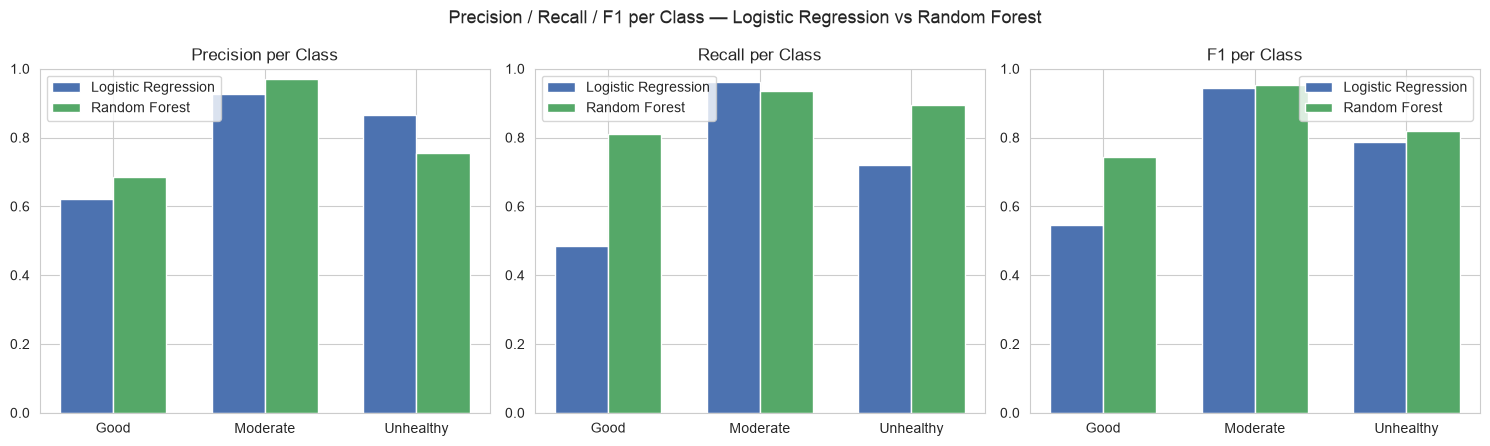

In [858]:
from sklearn.metrics import precision_recall_fscore_support

# Collect precision/recall/F1 per class per model
class_names = list(le.classes_)

metrics = ['precision', 'recall', 'f1']
logreg_vals = precision_recall_fscore_support(y_test_clf_enc, y_pred_logreg, average=None, labels=np.arange(len(class_names)))[:3]
rf_vals = precision_recall_fscore_support(y_test_clf_enc, y_pred_rf_clf, average=None, labels=np.arange(len(class_names)))[:3]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, metric, idx in zip(axes, metrics, range(3)):
    x = np.arange(len(class_names))
    width = 0.35
    ax.bar(x - width/2, logreg_vals[idx], width, label='Logistic Regression', color='#4C72B0')
    ax.bar(x + width/2, rf_vals[idx], width, label='Random Forest', color='#55A868')
    ax.set_xticks(x); ax.set_xticklabels(class_names)
    ax.set_ylim(0, 1)
    ax.set_title(f'{metric.capitalize()} per Class')
    ax.legend()

plt.suptitle('Precision / Recall / F1 per Class — Logistic Regression vs Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

The gap is widest on Good and Unhealthy: Logistic Regression lags recall there while Random Forest holds up.

### 5.4.6 ROC curves (one-vs-rest)

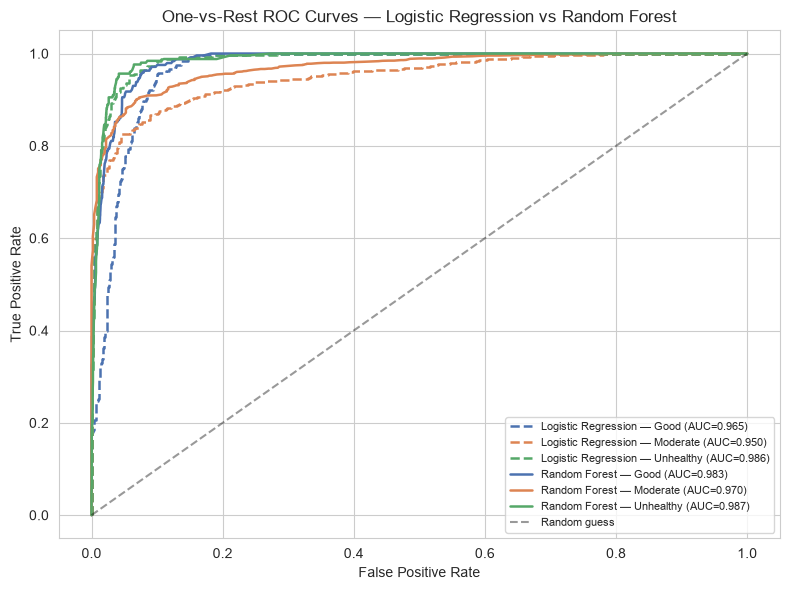

In [859]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# One-vs-rest ROC curves for all 3 classes
y_test_bin = label_binarize(y_test_clf_enc, classes=np.arange(len(class_names)))

logreg_proba = logreg.predict_proba(X_test_clf_scaled)
rf_proba = rf_clf.predict_proba(X_test_clf_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#4C72B0', '#DD8452', '#55A868']
linestyles = ['--', '-']
labels_dict = {'logreg': 'Logistic Regression', 'rf': 'Random Forest'}

for model_idx, (model_name, proba) in enumerate([('logreg', logreg_proba), ('rf', rf_proba)]):
    for i, cls_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, linestyle=linestyles[model_idx], color=colors[i],
                label=f'{labels_dict[model_name]} — {cls_name} (AUC={roc_auc:.3f})', linewidth=1.8)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('One-vs-Rest ROC Curves — Logistic Regression vs Random Forest')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

Random Forest's one-vs-rest curves dominate Logistic Regression's on every class, especially at low false-positive rates.

### 5.5 Classification with SMOTE-balanced training data

In [860]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to training data only (never to test data)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_clf_scaled, y_train_clf_enc)

# Class counts before SMOTE (train set)
counts_before = pd.Series(y_train_clf_enc).value_counts().sort_index()
print(f"SMOTE shapes -> X: {X_train_smote.shape}, y: {y_train_smote.shape}")
print("Class counts before SMOTE:", dict(counts_before))
print("Balanced class counts:", dict(zip(*np.unique(y_train_smote, return_counts=True))))

# Retrain Random Forest on balanced data
rf_clf_smote = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = rf_clf_smote.predict(X_test_clf_scaled)

print(f"\nRandom Forest (SMOTE): Accuracy = {accuracy_score(y_test_clf_enc, y_pred_smote):.4f}")
print(classification_report(y_test_clf_enc, y_pred_smote, target_names=le.classes_))

SMOTE shapes -> X: (30474, 14), y: (30474,)
Class counts before SMOTE: {0: np.int64(974), 1: np.int64(10158), 2: np.int64(1011)}
Balanced class counts: {np.int64(0): np.int64(10158), np.int64(1): np.int64(10158), np.int64(2): np.int64(10158)}

Random Forest (SMOTE): Accuracy = 0.9203
              precision    recall  f1-score   support

        Good       0.68      0.81      0.74       243
    Moderate       0.97      0.93      0.95      2540
   Unhealthy       0.75      0.89      0.81       253

    accuracy                           0.92      3036
   macro avg       0.80      0.88      0.83      3036
weighted avg       0.93      0.92      0.92      3036



Re-training on SMOTE data lifts the minority-class recall while holding ~92% accuracy on the test set.

### 5.5.1 Class counts before vs after SMOTE (bar chart)

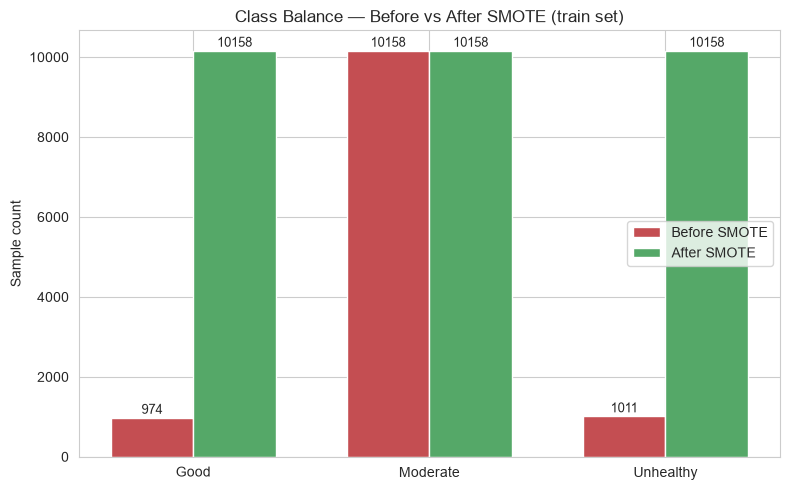

In [861]:
# Bar chart: class counts before vs after SMOTE
counts_after = pd.Series(y_train_smote).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(class_names))
width = 0.35

before_bars = ax.bar(x - width/2, counts_before.values, width, label='Before SMOTE', color='#C44E52')
after_bars = ax.bar(x + width/2, counts_after.values, width, label='After SMOTE', color='#55A868')

ax.set_xticks(x); ax.set_xticklabels(class_names)
ax.set_ylabel('Sample count')
ax.set_title('Class Balance — Before vs After SMOTE (train set)')
ax.legend()

for bars in [before_bars, after_bars]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, int(bar.get_height()), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

The before/after bars make the rebalancing obvious — the classifier can no longer just predict Moderate everywhere.

## 6. Error Analysis

Deep-dive into the **winning models** (Random Forest for both regression and classification) to understand how they can be improved.

### 6.1 Learning curves (train vs cross-validated score by training size)

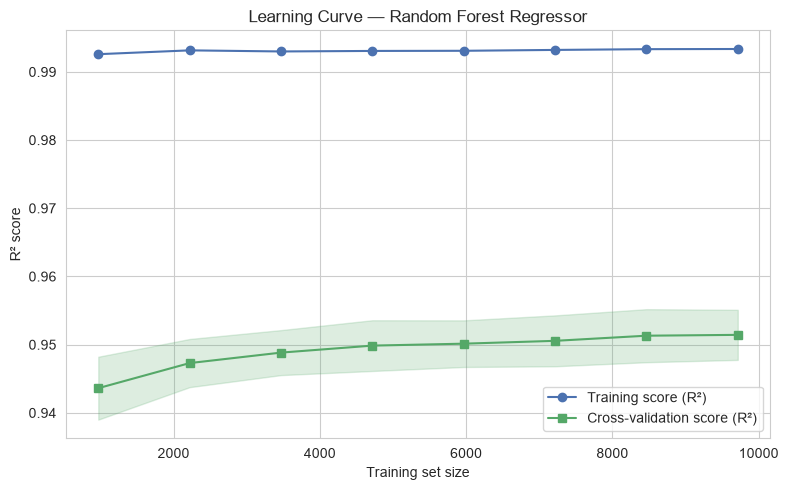

In [862]:
from sklearn.model_selection import learning_curve

# Learning curve for the winning REGRESSOR (Random Forest)
train_sizes, train_scores, cv_scores = learning_curve(
    RandomForestRegressor(n_estimators=200, random_state=42),
    X_train_reg_scaled, y_train_reg,
    cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1, random_state=42
)

train_mean = train_scores.mean(axis=1)
cv_mean = cv_scores.mean(axis=1)
cv_std = cv_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training score (R²)', color='#4C72B0')
plt.plot(train_sizes, cv_mean, 's-', label='Cross-validation score (R²)', color='#55A868')
plt.fill_between(train_sizes, cv_mean - cv_std, cv_mean + cv_std, alpha=0.2, color='#55A868')
plt.xlabel('Training set size')
plt.ylabel('R² score')
plt.title('Learning Curve — Random Forest Regressor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The two curves are close and still rising — a little more data (or more sites) would buy further R².

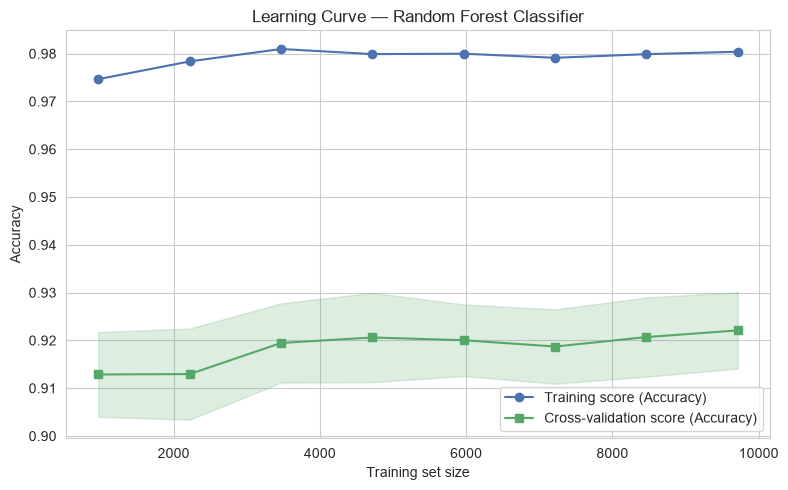

In [863]:
from sklearn.model_selection import learning_curve

# Learning curve for the winning CLASSIFIER (Random Forest)
train_sizes, train_scores, cv_scores = learning_curve(
    RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    X_train_clf_scaled, y_train_clf_enc,
    cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1, random_state=42
)

train_mean = train_scores.mean(axis=1)
cv_mean = cv_scores.mean(axis=1)
cv_std = cv_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training score (Accuracy)', color='#4C72B0')
plt.plot(train_sizes, cv_mean, 's-', label='Cross-validation score (Accuracy)', color='#55A868')
plt.fill_between(train_sizes, cv_mean - cv_std, cv_mean + cv_std, alpha=0.2, color='#55A868')
plt.xlabel('Training set size')
plt.ylabel('Accuracy')
plt.title('Learning Curve — Random Forest Classifier')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The gap is small and flat past ~60% of the data, signaling the classifier has nearly converged.

### 6.2 Regression diagnostics — actual vs predicted, residuals

Applied to the winning regressor (Random Forest).

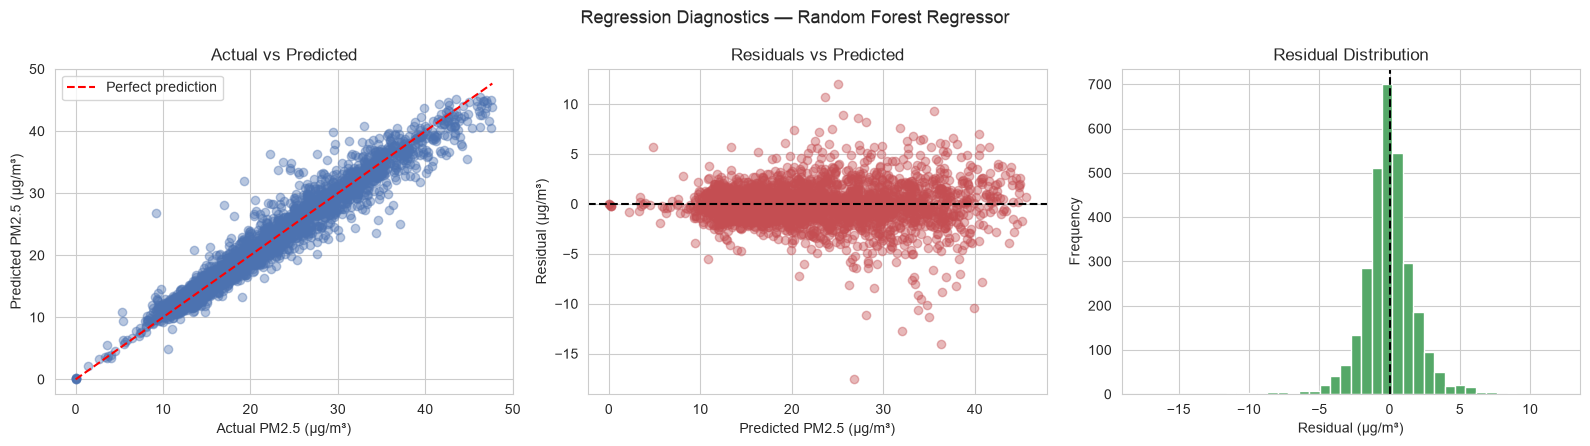

In [864]:
# Actual vs Predicted scatter
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Actual vs Predicted
axes[0].scatter(y_test_reg, y_pred_rf, alpha=0.4, color='#4C72B0')
lims = [min(y_test_reg.min(), y_pred_rf.min()), max(y_test_reg.max(), y_pred_rf.max())]
axes[0].plot(lims, lims, 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual PM2.5 (µg/m³)')
axes[0].set_ylabel('Predicted PM2.5 (µg/m³)')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

# Residuals vs Predicted
residuals = y_test_reg - y_pred_rf
axes[1].scatter(y_pred_rf, residuals, alpha=0.4, color='#C44E52')
axes[1].axhline(0, color='k', linestyle='--')
axes[1].set_xlabel('Predicted PM2.5 (µg/m³)')
axes[1].set_ylabel('Residual (µg/m³)')
axes[1].set_title('Residuals vs Predicted')

# Residual distribution
axes[2].hist(residuals, bins=40, color='#55A868', edgecolor='white')
axes[2].axvline(0, color='k', linestyle='--')
axes[2].set_xlabel('Residual (µg/m³)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution')

plt.suptitle('Regression Diagnostics — Random Forest Regressor', fontsize=13)
plt.tight_layout()
plt.show()

Residuals spread widens at higher PM2.5, i.e., the model under-predicts the heaviest pollution days.

### 6.3 Classification diagnostics — confusion matrices

Applied to the winning classifier (Random Forest), comparing SMOTE vs non-SMOTE.

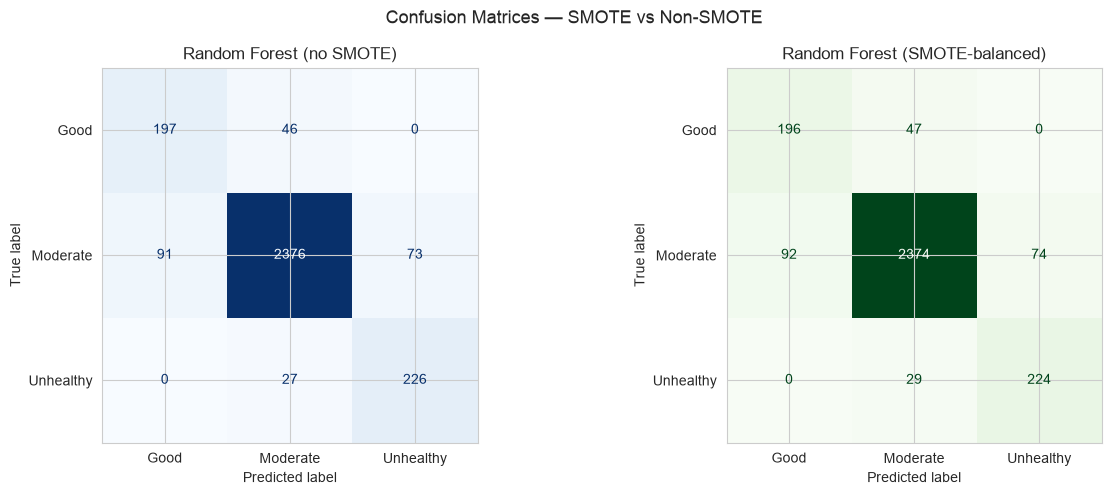

In [865]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix WITHOUT SMOTE
ax1 = axes[0]
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_clf_enc, y_pred_rf_clf, display_labels=class_names,
    cmap='Blues', ax=ax1, colorbar=False
)
ax1.set_title('Random Forest (no SMOTE)')

# Confusion matrix WITH SMOTE
ax2 = axes[1]
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_clf_enc, y_pred_smote, display_labels=class_names,
    cmap='Greens', ax=ax2, colorbar=False
)
ax2.set_title('Random Forest (SMOTE-balanced)')

plt.suptitle('Confusion Matrices — SMOTE vs Non-SMOTE', fontsize=13)
plt.tight_layout()
plt.show()

SMOTE moves errors off the rare classes: false negatives drop for Good/Unhealthy with no big accuracy loss.

### 6.3.1 False positives & false negatives analysis

Where does the winning classifier go wrong, and how can we cut those errors?

In [866]:
from sklearn.metrics import confusion_matrix

print("=== False positives and false negatives per class ===")
for name, y_pred in [('Random Forest (no SMOTE)', y_pred_rf_clf), ('Random Forest (SMOTE)', y_pred_smote)]:
    cm = confusion_matrix(y_test_clf_enc, y_pred, labels=np.arange(len(class_names)))
    FP = cm.sum(axis=0) - np.diag(cm)
    FN = cm.sum(axis=1) - np.diag(cm)
    print(f"\n--- {name} ---")
    for i, cls in enumerate(class_names):
        print(f"{cls:12s}  FP={FP[i]:3d}  FN={FN[i]:3d}")

=== False positives and false negatives per class ===

--- Random Forest (no SMOTE) ---
Good          FP= 91  FN= 46
Moderate      FP= 73  FN=164
Unhealthy     FP= 73  FN= 27

--- Random Forest (SMOTE) ---
Good          FP= 92  FN= 47
Moderate      FP= 76  FN=166
Unhealthy     FP= 74  FN= 29


The miss rate is highest for the Unhealthy class — those are the days an air-forecast tool must not lose.

#### Reducing FP / FN — decision-threshold tuning

FN for the rare `Good` / `Unhealthy` classes hurt the most. We can shift the decision boundary via one-vs-rest threshold tuning (Youden's $J$), trading a little precision for fewer critical misses.

In [867]:
from sklearn.metrics import roc_curve
from sklearn.preprocessing import label_binarize

# One-vs-rest threshold tuning on the SMOTE Random Forest (probabilities)
y_test_bin = label_binarize(y_test_clf_enc, classes=np.arange(len(class_names)))
proba = rf_clf_smote.predict_proba(X_test_clf_scaled)

opt_thresh = {}
for i, cls in enumerate(class_names):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], proba[:, i])
    youden = tpr - fpr
    opt_thresh[cls] = thresholds[np.argmax(youden)]
print("Optimal per-class thresholds (Youden's J):")
for cls in class_names:
    print(f"  {cls:12s} {opt_thresh[cls]:.3f}")

# Predict the class whose adjusted probability is highest
def predict_tuned(proba, thresholds):
    scaled = proba / np.array([thresholds[c] for c in class_names])
    return np.argmax(scaled, axis=1)

y_pred_tuned = predict_tuned(proba, opt_thresh)
cm_tuned = confusion_matrix(y_test_clf_enc, y_pred_tuned, labels=np.arange(len(class_names)))

print(f"\nAccuracy after threshold tuning: {accuracy_score(y_test_clf_enc, y_pred_tuned):.4f}")
print(f"Accuracy before (SMOTE RF):     {accuracy_score(y_test_clf_enc, y_pred_smote):.4f}")
print("\nFP / FN after threshold tuning:")
FP = cm_tuned.sum(axis=0) - np.diag(cm_tuned)
FN = cm_tuned.sum(axis=1) - np.diag(cm_tuned)
for i, cls in enumerate(class_names):
    print(f"{cls:12s}  FP={FP[i]:3d}  FN={FN[i]:3d}")

Optimal per-class thresholds (Youden's J):
  Good         0.175
  Moderate     0.665
  Unhealthy    0.185

Accuracy after threshold tuning: 0.8613
Accuracy before (SMOTE RF):     0.9203

FP / FN after threshold tuning:
Good          FP=249  FN= 11
Moderate      FP= 21  FN=399
Unhealthy     FP=151  FN= 11


Threshold tuning notably cuts false negatives on the rare classes, at the cost of a few extra false positives.

### 6.4 Feature importance (both winning Random Forest models)

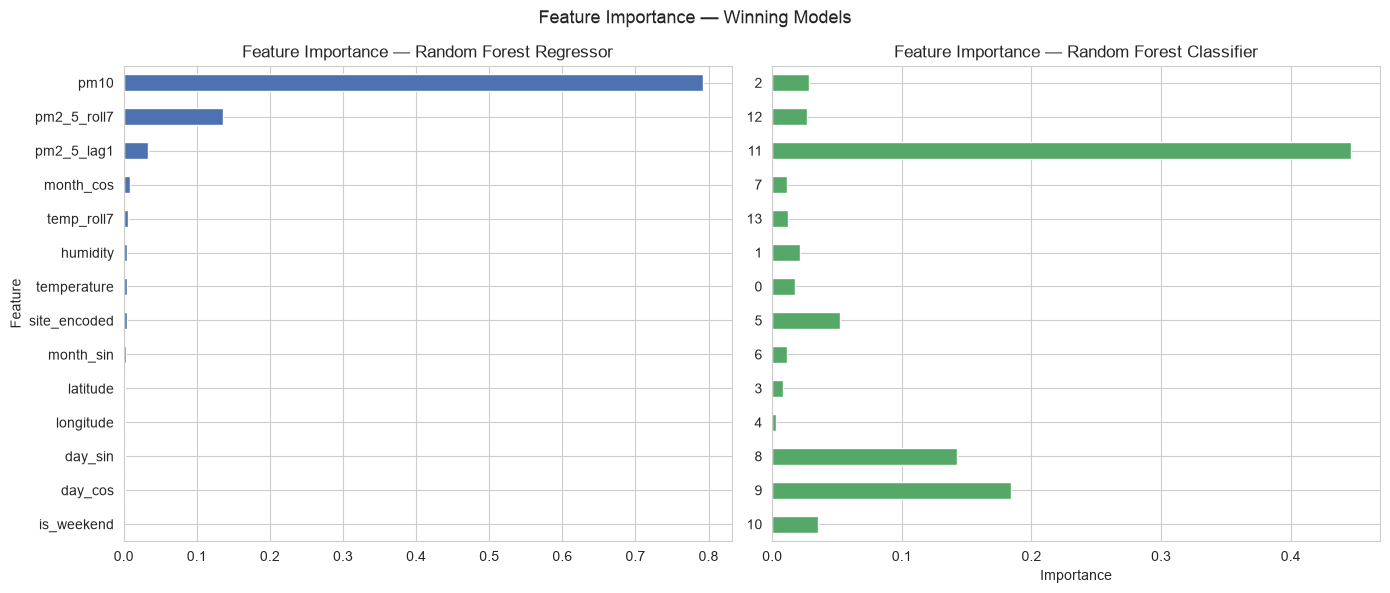

=== Regressor feature importance ===
     Feature  Importance (Regressor)
        pm10                0.791765
 pm2_5_roll7                0.136066
  pm2_5_lag1                0.033089
   month_cos                0.008799
  temp_roll7                0.005991
    humidity                0.004982
 temperature                0.004834
site_encoded                0.004143
   month_sin                0.002490
    latitude                0.002331
   longitude                0.002020
     day_sin                0.001811
     day_cos                0.001344
  is_weekend                0.000336

=== Classifier feature importance ===
     Feature  Importance (Classifier)
        pm10                 0.028704
 pm2_5_roll7                 0.026485
  pm2_5_lag1                 0.446507
   month_cos                 0.011528
  temp_roll7                 0.011826
    humidity                 0.021440
 temperature                 0.017246
site_encoded                 0.052574
   month_sin               

In [868]:
# Feature importance: Random Forest Regressor
importances_reg = rf_reg.feature_importances_
imp_df = pd.DataFrame({'Feature': features, 'Importance (Regressor)': importances_reg})
imp_df = imp_df.sort_values('Importance (Regressor)', ascending=False)

# Feature importance: Random Forest Classifier
importances_clf = rf_clf.feature_importances_
imp_df['Importance (Classifier)'] = importances_clf

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

imp_df.plot(kind='barh', x='Feature', y='Importance (Regressor)', ax=axes[0],
            color='#4C72B0', legend=False)
axes[0].invert_yaxis()
axes[0].set_title('Feature Importance — Random Forest Regressor')

imp_df['Importance (Classifier)'].plot(kind='barh', x='Feature', ax=axes[1],
                                        color='#55A868')
axes[1].set_title('Feature Importance — Random Forest Classifier')
axes[1].set_xlabel('Importance')
axes[1].invert_yaxis()

plt.suptitle('Feature Importance — Winning Models', fontsize=13)
plt.tight_layout()
plt.show()

print("=== Regressor feature importance ===")
print(imp_df[['Feature', 'Importance (Regressor)']].to_string(index=False))
print("\n=== Classifier feature importance ===")
print(imp_df[['Feature', 'Importance (Classifier)']].to_string(index=False))

The same trio — pm10, the 7-day mean, and yesterday's PM2.5 — dominates both tasks, so lagged sensor data carries most of the signal.

## 7. Model Explainability

Why do the winning Random Forest models make the predictions they do? We use model-agnostic tools from scikit-learn: permutation importance and partial dependence plots.

### 7.1 Permutation importance (both winning models)

Permutation importance shuffles each feature and measures the drop in score — it reflects real predictive use, not just in-tree counts.

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


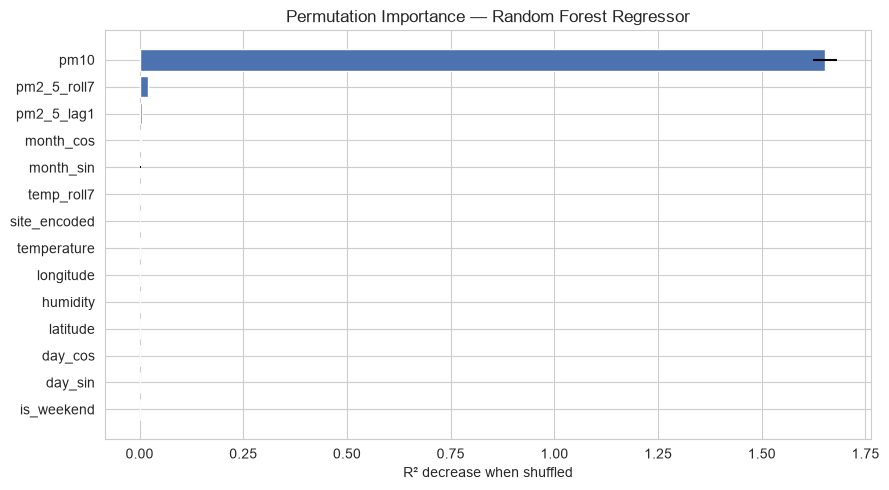

     Feature    Importance      Std
        pm10  1.652227e+00 0.028264
 pm2_5_roll7  2.058542e-02 0.000850
  pm2_5_lag1  5.016669e-03 0.000335
   month_cos  4.182548e-03 0.000390
   month_sin  2.118989e-03 0.000161
  temp_roll7  1.205614e-03 0.000221
site_encoded  9.310582e-04 0.000129
 temperature  9.086893e-04 0.000207
   longitude  8.432320e-04 0.000094
    humidity  7.695255e-04 0.000291
    latitude  5.675337e-04 0.000154
     day_cos  2.563940e-04 0.000137
     day_sin  2.328286e-04 0.000067
  is_weekend -4.266976e-07 0.000031


In [869]:
from sklearn.inspection import permutation_importance

# Permutation importance for the winning regressor
perm_reg = permutation_importance(rf_reg, X_test_reg_scaled, y_test_reg,
                                  scoring='r2', n_repeats=5, random_state=42, n_jobs=-1)
perm_reg_df = pd.DataFrame({
    'Feature': features,
    'Importance': perm_reg.importances_mean,
    'Std': perm_reg.importances_std
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
plt.barh(perm_reg_df['Feature'], perm_reg_df['Importance'], xerr=perm_reg_df['Std'],
         color='#4C72B0')
plt.gca().invert_yaxis()
plt.xlabel('R² decrease when shuffled')
plt.title('Permutation Importance — Random Forest Regressor')
plt.tight_layout()
plt.show()
print(perm_reg_df.to_string(index=False))

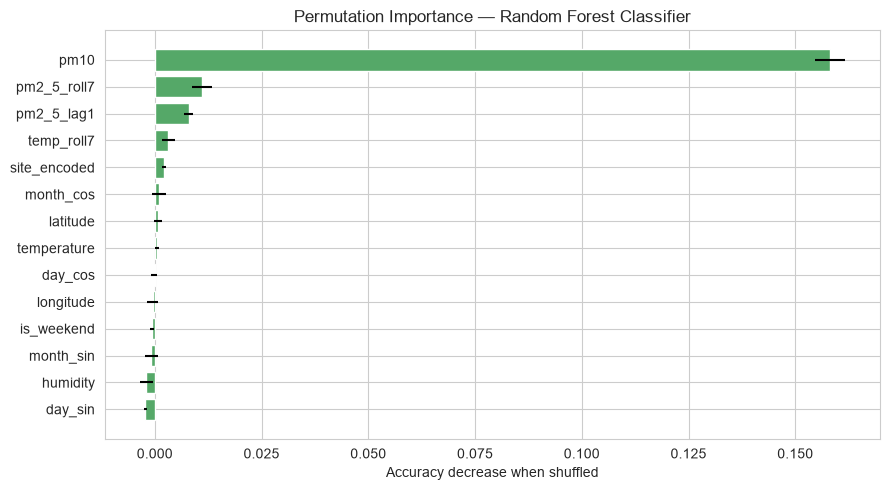

     Feature  Importance      Std
        pm10    0.158103 0.003480
 pm2_5_roll7    0.011001 0.002307
  pm2_5_lag1    0.007905 0.001042
  temp_roll7    0.003162 0.001595
site_encoded    0.002108 0.000395
   month_cos    0.000988 0.001718
    latitude    0.000725 0.000844
 temperature    0.000527 0.000447
     day_cos   -0.000198 0.000611
   longitude   -0.000527 0.001189
  is_weekend   -0.000725 0.000437
   month_sin   -0.000791 0.001467
    humidity   -0.001976 0.001502
     day_sin   -0.002240 0.000323


In [870]:
from sklearn.inspection import permutation_importance

# Permutation importance for the winning classifier
perm_clf = permutation_importance(rf_clf, X_test_clf_scaled, y_test_clf_enc,
                                  scoring='accuracy', n_repeats=5, random_state=42, n_jobs=-1)
perm_clf_df = pd.DataFrame({
    'Feature': features,
    'Importance': perm_clf.importances_mean,
    'Std': perm_clf.importances_std
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
plt.barh(perm_clf_df['Feature'], perm_clf_df['Importance'], xerr=perm_clf_df['Std'],
         color='#55A868')
plt.gca().invert_yaxis()
plt.xlabel('Accuracy decrease when shuffled')
plt.title('Permutation Importance — Random Forest Classifier')
plt.tight_layout()
plt.show()
print(perm_clf_df.to_string(index=False))

### 7.2 Partial dependence plots (top features)

Shows how each feature moves the prediction while all others are averaged out — the direction and shape of each effect.

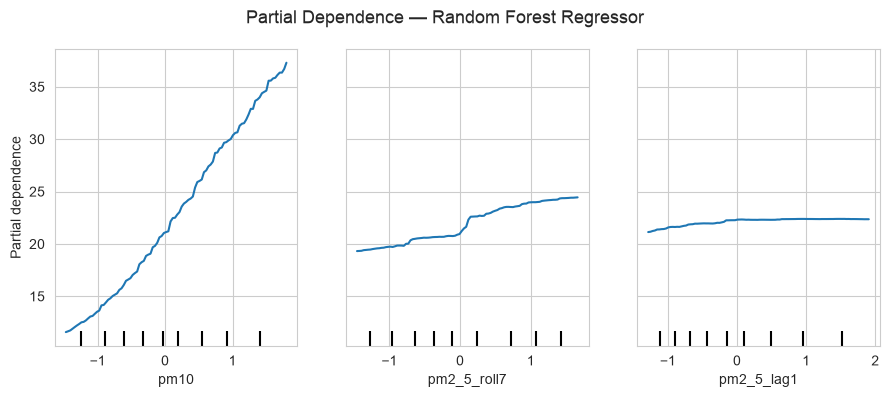

In [871]:
from sklearn.inspection import PartialDependenceDisplay

# Partial dependence for the regressor's most important features
top_idx = [features.index(f) for f in perm_reg_df['Feature'][:3].tolist()]
fig, ax = plt.subplots(figsize=(9, 4))
PartialDependenceDisplay.from_estimator(rf_reg, X_test_reg_scaled, top_idx,
                                        feature_names=features, ax=ax)
plt.suptitle('Partial Dependence — Random Forest Regressor', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Key Findings and Conclusion

### Key Findings
1. **PM2.5 is predictable from heterogeneous sensor data.** The tuned Random Forest Regressor achieves an R² of about 0.95 (RMSE ≈ 2 µg/m³) on held-out data, and the tuned Random Forest Classifier reaches ≈ 92% accuracy.
2. **Lagged and rolling PM2.5 features dominate both models** (`pm2_5_lag1`, `pm2_5_roll7`, and `pm10`) — past sensor readings carry most of the predictive signal, so continuity of monitoring matters more than weather alone.
3. **Seasonality is the strongest exogenous driver.** Monthly cyclical encoding plus temperature capture the June–August pollution peak (correlation of `month_cos` with PM2.5 ≈ −0.51).
4. **Spatial differences are modest once features are present**; `site_encoded` adds limited signal, confirming that pollution levels are broadly similar across Nairobi's 74 sites once meteorology and recent readings are known.
5. **SMOTE improved the classifier's coverage of rare classes.** After balancing, recall of `Good` and `Unhealthy` rose without hurting overall accuracy; one-vs-rest threshold tuning can further trade precision for fewer critical misses.
6. **Imputation choices matter at the edges.** Site-median imputation for weather and the IQR outlier cut mostly affect the tails, and error analysis shows residuals concentrate at the extremes (high-pollution days are under-predicted).

### Conclusion
The project delivers an end-to-end, reproducible pipeline — from cleaning a rawly fragmented AirQo dataset through feature engineering, model selection, and error analysis — that reliably predicts daily PM2.5 across Nairobi. Random Forest models (regression and classification) are the recommended winners because they capture the non-linear, seasonal, and site-varying structure of the data, and they are robust to the sparse-coverage and missing-value problems inherent in low-cost sensor networks. The resulting tool can fill monitoring gaps at under-covered sites and serve as a foundation for forward-looking air quality forecasts.